# I. Installations and Imported Packages

In [1]:
# !pip install -q transformers datasets wandb

In [2]:
import os
import time
import random
import glob
import multiprocessing
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F_audio
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

from kaggle_secrets import UserSecretsClient
import wandb

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score

from pathlib import Path
from tqdm import tqdm

from transformers import AutoFeatureExtractor, ASTForAudioClassification, get_cosine_schedule_with_warmup

import warnings
warnings.filterwarnings("ignore")

print(time.ctime())
print("All libraries are imported")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Mon Apr  6 14:25:05 2026
All libraries are imported


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# II. User Defined Control Variable

Setting the flag variable **execute_milestone_solutions_code** as **False** ignore the exection of the cells containing the milestone solution code

In [4]:
execute_milestone_solutions_code=False
print(f"Exceting the milestone solution code cells: {execute_milestone_solutions_code}")

Exceting the milestone solution code cells: False


# III. Weights & Biases Setup

In [5]:
secret_label = "WANDB_API_KEY" 
secret_value = UserSecretsClient().get_secret(secret_label)
os.environ['WANDB_API_KEY'] = secret_value
wandb.login()

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

### Test run of W&B

In [6]:
if execute_milestone_solutions_code:
    for run in range(5):
        # Start a new wandb run to track this script.
        run = wandb.init(
            # Set the wandb entity where your project will be logged (generally your team name).
            entity="21f2000660-dl-gen-ai-project-26-t1",
            # Set the wandb project where this run will be logged.
            project="21f2000660-t12026",
            # Track hyperparameters and run metadata.
            config={
                "learning_rate": 0.02,
                "architecture": "CNN",
                "dataset": "CIFAR-100",
                "epochs": 10,
            },
        )
    
    # Simulate training.
    epochs = 10
    offset = random.random() / 5
    for epoch in range(2, epochs):
        acc = 1 - 2**-epoch - random.random() / epoch - offset
        loss = 2**-epoch + random.random() / epoch + offset
    
        # Log metrics to wandb.
        run.log({"acc": acc, "loss": loss})
    
    # Finish the run and upload any remaining data.
    run.finish()

# IV. Milestone Solutions
## Milestone 1

This milestone focuses on understanding the dataset and establishing a baseline performance through **exploratory data analysis (EDA)** and simple **heuristic-based methods** using `librosa`.

---

### Suggested Readings
- [Hugging Face Audio Course](https://huggingface.co/learn/audio-course/en/chapter0/introduction)
- [Librosa Documentation](https://librosa.org/doc/main/core.html#audio-loading)

---

### Instructions
Use this notebook to answer **all Milestone-1 questions**.

---

### Resources
- Notebook Link:  
  https://colab.research.google.com/drive/1m6UczhxQIke_raWSqukSWuiKbIVt7MMb?usp=sharing  

- Competition Link:  
  https://www.kaggle.com/competitions/jan-2026-dl-gen-ai-project/


In [7]:
if execute_milestone_solutions_code:
    #----------------------------- DON'T CHANGE THIS --------------------------
    DATA_SEED = 67
    TRAINING_SEED = 1234
    SR = 22050
    DURATION = 5.0
    N_FFT = 2048
    HOP_LENGTH = 512
    N_MELS = 128
    TOP_DB=20
    TARGET_SNR_DB = 10
    
    random.seed(DATA_SEED)
    np.random.seed(DATA_SEED)
    torch.manual_seed(DATA_SEED)
    torch.cuda.manual_seed(DATA_SEED)

In [8]:
if execute_milestone_solutions_code:
    # CONFIGURATION
    path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'
    DATA_ROOT = path # Enter dataset path
    
    with os.scandir(path) as entries:
        directories = [entry.name for entry in entries]
    
    GENRES = sorted(directories) # Make the list of all genres available (alphabetical order)
    print(GENRES)
    
    STEMS = {'drums':'drums.wav', 'vocals':'vocals.wav', 'bass':'bass.wav', 'other':'other.wav'} # Write here stems file name
    print(STEMS)
    
    STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
    GENRE_TO_TEST = 'rock'
    SONG_INDEX = 0 #Enter index as per Q10.

In [9]:
if execute_milestone_solutions_code:
    def build_dataset(root_dir, val_split=0.17, seed=42):
        # Initialize empty dictionaries
        train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
        val_dataset   = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    
        #print(train_dataset)
    
        rng = random.Random(seed)
    
        # ------------------- write your code here -------------------------------
    
            # Iterate through Genres
            # Check: if genre folder exists
            # CHECK : Completeness (Does it have all stems?)
            # CHECK : Corruption (Is any file too small? (less than 4kb))
            # size checks
            # Stratified Shuffle Split
         #-------------------------------------------------------------------------
    
        # Limits given in the questions
        limit_1 = 4 * 1024
        limit_2 = 5.0491 * 1024 * 1024
        limit_3 = 5.0493 * 1024 * 1024
    
        corrupted_songs = 0
        small_songs = 0
        large_songs = 0
        
        # Helper function to populate dict
        def add_to_dict(target_dict, genre, song_paths):
            for song_path in song_paths:
                for stem_key, stem_file in STEMS.items():
                    target_dict[genre][stem_key].append(os.path.join(song_path, stem_file))
    
        for genre in GENRES:
            genre_path = os.path.join(root_dir, genre)
            
            # Check: if genre folder exists
            if not os.path.isdir(genre_path):
                continue
                
            # Get all song folders
            song_folders = sorted([f.path for f in os.scandir(genre_path) if f.is_dir()])
            valid_songs = []
    
            #print(song_folders[:3])
    
            for song in song_folders:
                is_valid = True
                
                # All stems for a song should be available, if not invalid 
                for stem_file in STEMS.values():
                    file_path = os.path.join(song, stem_file)
                    
                    if not os.path.exists(file_path):
                        is_valid = False
                        continue
                    
                    file_size = os.path.getsize(file_path)
                    
                    if file_size < limit_1:
                        corrupted_songs += 1
                        is_valid = False
                    
                    if file_size < limit_2:
                        small_songs += 1
                        
                    if file_size > limit_3:
                        large_songs += 1
    
                if is_valid:
                    valid_songs.append(song)
    
            # Stratified Shuffle Split
            rng.shuffle(valid_songs)
            
            split_index = int(len(valid_songs) * (1 - val_split))
            train_paths = valid_songs[:split_index]
            val_paths = valid_songs[split_index:]
            
            add_to_dict(train_dataset, genre, train_paths)
            add_to_dict(val_dataset, genre, val_paths)
    
        print('Q1',corrupted_songs + small_songs)
        print(corrupted_songs,small_songs,large_songs)
        print('Q2',abs(large_songs - small_songs))
        print('Q3',abs(len(train_dataset['reggae']['drums']) - len(val_dataset['country']['vocals'])))
    
        return train_dataset, val_dataset
    
    tr, val = build_dataset(DATA_ROOT)
    
    #print(val[GENRE_TO_TEST])

In [10]:
if execute_milestone_solutions_code:
    def find_long_silences(dataset_dict, sr=SR, threshold_sec=DURATION, top_db=TOP_DB):
        """
        Input:
            dataset_dict: The dictionary structure {genre: {stem: [paths...]}}
        Output:
            df: Pandas DataFrame containing details of all files with silence >= 5s
        """
        records = []
        # ------------------- write your code here -------------------------------
    
        total_files = 0    # ---- COUNT TOTAL FILES ----
    
    
    
            # Load Audio
    
            # Find Non-Silent Intervals
    
            # CASE A: Fully silent
            # CASE B: START silence
            # CASE C: END silence
            # CASE D: MIDDLE silence
    
            # Store result
            # if max_silence >= threshold_sec:
            #     records.append({
            #         "Genre": genre,
            #         "Stem": stem_name,
            #         "Duration": round(total_duration, 2),
            #         "Max_Silence_Sec": round(max_silence, 2),
            #         "Silence_Location": ", ".join(silence_type),
            #         "File_Path": file_path
            #     })
        #-------------------------------------------------------------------------
    
        # Iterate through the nested dictionary
        for genre, stems in dataset_dict.items():
            for stem_name, file_paths in stems.items():
                for file_path in file_paths:
                    total_files += 1
                    
                    # Load Audio
                    y, sr = librosa.load(file_path, sr=sr)
                    total_duration = librosa.get_duration(y=y, sr=sr)
    
                    # Find Non-Silent Intervals
                    # intervals is a list of [start, end] sample indices of NON-silence
                    intervals = librosa.effects.split(y, top_db=top_db)
                    
                    silence_durations = []
                    silence_type = []
    
                    # CASE A: Fully silent
                    if len(intervals) == 0:
                        max_silence = total_duration
                        silence_type.append("Full")
                    else:
                        # CASE B: START silence (from 0 to first non-silent start)
                        if intervals[0][0] > 0:
                            start_silence = intervals[0][0] / sr
                            silence_durations.append(start_silence)
                            if start_silence >= threshold_sec:
                                 silence_type.append("Start")
    
                        # CASE C: END silence (from last non-silent end to total length)
                        if intervals[-1][1] < len(y):
                            end_silence = (len(y) - intervals[-1][1]) / sr
                            silence_durations.append(end_silence)
                            if end_silence >= threshold_sec:
                                 silence_type.append("End")
    
                        # CASE D: MIDDLE silence (gaps between intervals)
                        for i in range(len(intervals) - 1):
                            silence_gap = (intervals[i+1][0] - intervals[i][1]) / sr
                            silence_durations.append(silence_gap)
                            if silence_gap >= threshold_sec:
                                 silence_type.append("Middle")
                        
                        # Determine max silence for this file
                        if silence_durations:
                            max_silence = max(silence_durations)
                        else:
                            max_silence = 0.0
    
                    # Store result
                    if max_silence >= threshold_sec:
                        records.append({
                            "Genre": genre,
                            "Stem": stem_name,
                            "Duration": round(total_duration, 2),
                            "Max_Silence_Sec": round(max_silence, 4),
                            "Silence_Location": ", ".join(set(silence_type)),
                            "File_Path": file_path
                        })
        df = pd.DataFrame(records)
        return df
    
    
    # --- EXECUTION ---
    # Pass your 'tr' (training) dictionary here.
    # Ensure 'tr' is defined from your previous build_dataset code.
    df_silence = find_long_silences(tr, threshold_sec=DURATION, top_db=TOP_DB)
    
    # --- RESULTS ANALYSIS ---
    
    # ------------------- write your code here -------------------------------
    
    print('Q4',len(df_silence))
    print('Q5',len(df_silence[df_silence['Stem'] == 'vocals']))
    print('Q6',df_silence[df_silence['Stem'] == 'vocals']['Max_Silence_Sec'].mean())
    print('Q7',len(df_silence[(df_silence['Genre'] == 'jazz') & (df_silence['Stem'] == 'drums')]))
    print('Q8',len(df_silence[(df_silence['Genre'] == 'jazz') & (df_silence['Stem'] == 'drums') & (df_silence['Silence_Location'] == 'Middle')]))
    print('Q9',len(df_silence[(df_silence['Genre'] == 'jazz') & (df_silence['Stem'] == 'drums') & (df_silence['Max_Silence_Sec'] >= 10.0)]))
    #-------------------------------------------------------------------------
    # Hint: Create a pivot Table: Count by Genre vs Stem
    
    pivot_table = df_silence.pivot_table(index='Genre', columns='Stem', values='Max_Silence_Sec', aggfunc='count', fill_value=0)
    print("\n--- Pivot Table ---")
    print(pivot_table)

In [11]:
if execute_milestone_solutions_code:
    stems_audio = []
    try:
        for key in STEM_KEYS:
        # ------------------- write your code here -------------------------------
        # Load audio (Duration 5.0s for speed/consistency)
            file_path = tr[GENRE_TO_TEST][key][SONG_INDEX]
    
            y, sr = librosa.load(file_path, sr=SR, duration=DURATION)
            stems_audio.append(y)
        #-------------------------------------------------------------------------
    
        print("Audio loaded successfully.")
    except NameError:
        print("ERROR: 'tr' dictionary not found. Please run build_dataset() first.")
    except IndexError:
        print(f"ERROR: Song index {SONG_INDEX} out of range for genre {GENRE_TO_TEST}.")
    except Exception as e:
        print(f"ERROR: {e}")

In [12]:
if execute_milestone_solutions_code:
    # ------------------- write your code here -------------------------------
    # Stack them into a numpy array (Shape: 4 x Samples)
    stems_stack = np.vstack(stems_audio)
    
    # Mix the stems by summing them element-wise
    mix_raw = np.sum(stems_stack, axis=0)
    
    # Calculate RMS Amplitude MANUALLY
    rms_val = np.sqrt(np.mean(mix_raw**2))
    
    #Peak Normalization
    max_val = np.max(np.abs(mix_raw))
    
    if max_val > 0:
        mix_norm = mix_raw / max_val
    else:
        mix_norm = mix_raw
    
    # VALIDATION
    assert np.isclose(np.max(np.abs(mix_norm)), 1.0), "Normalization failed."
    #------------------------------------------------------------------------
    
    print('Q10',len(mix_raw))
    print('Q11',rms_val)
    print('Q12',max_val)

## Milestone 2

In [13]:
if execute_milestone_solutions_code:
    #Mean duration of Jazz stems

    jazz_durations = []
    for stem_dict in tr.get('jazz').values():
        for file_path in stem_dict:
            dur = librosa.get_duration(path=file_path)
            jazz_durations.append(dur)
    
    mean_jazz_dur = np.mean(jazz_durations)
    print('Q1',mean_jazz_dur)

In [14]:
if execute_milestone_solutions_code:
    #Unique sample rates
    unique_srs = set()
    for genre, stems in tr.items():
        for stem_name, file_paths in stems.items():
            for file_path in file_paths:
                file_sr = librosa.get_samplerate(file_path)
                unique_srs.add(file_sr)
    
    print('Q2', unique_srs)

In [15]:
if execute_milestone_solutions_code:
    #Corrupted or zero-byte files
    zero_byte_count = 0
    for genre, stems in tr.items():
        for stem_name, file_paths in stems.items():
            for file_path in file_paths:
                if os.path.getsize(file_path) == 0:
                    zero_byte_count += 1
    
    print('Q3',zero_byte_count)

In [16]:
if execute_milestone_solutions_code:
    #Average peak amplitude for vocal stems
    
    vocal_peak_dbs = []
    for genre, stems in tr.items():
        vocal_files = stems.get('vocals')
        for file_path in vocal_files:
            y, sr = librosa.load(file_path, sr=SR)
            peak_amp = np.max(np.abs(y))
            peak_db = 20 * np.log10(max(peak_amp, 1e-10))
            vocal_peak_dbs.append(peak_db)
    
    avg_vocal_peak_db = np.mean(vocal_peak_dbs)
    print('Q4',avg_vocal_peak_db)

In [17]:
if execute_milestone_solutions_code:
    #Spectral Centroids
    genre_mean_centroids = {}
    
    for genre, stems in tr.items():
        genre_centroids = []
        for stem_name, file_paths in stems.items():
            for file_path in file_paths:
                y, _ = librosa.load(file_path, sr=SR)
                # Compute spectral centroid
                sc = librosa.feature.spectral_centroid(y=y, sr=SR)
                # Take the mean centroid of this specific file
                genre_centroids.append(np.mean(sc))
                
        if genre_centroids:
            genre_mean_centroids[genre] = np.mean(genre_centroids)
    
    print(genre_mean_centroids)
    
    blues_centroid = genre_mean_centroids.get('blues')
    print('Q5',blues_centroid)
    
    highest_sc_genre = max(genre_mean_centroids, key=genre_mean_centroids.get)
    print('Q6',highest_sc_genre)

In [18]:
if execute_milestone_solutions_code:
    #Silence in the first 0.5 seconds
    silence_count = 0
    for genre, stems in tr.items():
        for stem_name, file_paths in stems.items():
            for file_path in file_paths:
                y_start, sr = librosa.load(file_path, sr=SR, duration=0.5)
                
                intervals = librosa.effects.split(y_start, top_db=TOP_DB)
                
                if len(intervals) == 0 or intervals[0][0] > 0:
                    silence_count += 1
    
    print('Q7',silence_count)

### Programming Question

Complete the code as instructed in comments and answer the questions that follow.

In [19]:
if execute_milestone_solutions_code:
    # --- 1. Setup and Preprocessing ---
    ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
    STEMS_PATH = os.path.join(ROOT, 'genres_stems')
    GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
    
    def extract_features(song_path):
        # Load 10s at 22050Hz
        y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        return [float(tempo), spec_cent, zcr, rolloff]
    
    # --- 2. Data Preparation & Stratified Split ---
    data = []
    for g in GENRES:
        gp = os.path.join(STEMS_PATH, g)
        songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
        for s in songs[:50]: # Sampling 50 for speed; use all for final
            data.append({'path': os.path.join(gp, s), 'genre': g})
    
    df = pd.DataFrame(data)
    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)
    
    # --- 3. Model Training (Decision Tree) ---
    X_train = np.array([extract_features(p) for p in train_df['path']])
    y_train = train_df['genre']
    X_val = np.array([extract_features(p) for p in val_df['path']])
    y_val = val_df['genre']
    
    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_train, y_train)
    
    '''
    YOUR CODE HERE
    
    y_pred = # COMPUTE PREDICTED VALUES
    macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
    cm = # COMPUTE CONFUSION MATRIX
    cr = # COMPUTE CLASSIFICATION REPORT
    
    '''
    
    y_pred = clf.predict(X_val)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    cm = confusion_matrix(y_val, y_pred, labels=GENRES)
    cr = classification_report(y_val, y_pred, target_names=GENRES)
    
    print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
    print("Detailed Classification Report:")
    print(cr)

In [20]:
if execute_milestone_solutions_code:
    
    '''
    YOUR CODE HERE
    
    Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
    '''
    # Visualize Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=GENRES, yticklabels=GENRES)
    plt.title('Confusion Matrix: Decision Tree')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print('\n')
    print('--- TP, TN, FP, FN for all genres  ---')
    for i,genre in enumerate(GENRES):
        tp=cm[i, i]
        fp=cm[:, i].sum()-tp
        fn=cm[i, :].sum()-tp
        tn=cm.sum()-(tp+fp+fn)
            
        print(genre,"\t\t",tp,tn,fp,fn)

## Milestone 4

### Provided Helper Functions

In [21]:
if execute_milestone_solutions_code:
    # directory paths
    INPUT_BASE = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
    WORKING_BASE = '/kaggle/working'
    
    STEMS_PATH = os.path.join(INPUT_BASE, 'genres_stems')
    NOISE_PATH = os.path.join(INPUT_BASE, 'ESC-50-master/audio')
    OUTPUT_PATH = os.path.join(WORKING_BASE, 'synthetic_mashups/train')

In [22]:
if execute_milestone_solutions_code:
    # provided helper function 1
    
    def seed_everything(seed=42):
        """Locks all random seeds for absolute reproducibility."""
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
        # If using GPU
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            # Forces deterministic algorithms
            torch.backends.cudnn.deterministic = True 
            torch.backends.cudnn.benchmark = False
    
    # Execute immediately at the top of the script
    seed_everything(42)

In [23]:
if execute_milestone_solutions_code:
    # provided helper function 2
    
    def generate_synthetic_dataset(stems_dir, noise_dir, output_dir, samples_per_genre=50, target_sr=22050, duration=30):
        """Generates deterministic noisy mashups and saves them to /kaggle/working/."""
        genres = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
        target_length = target_sr * duration
        
        # Get noise files from read-only input
        noise_files = glob.glob(os.path.join(noise_dir, '**', '*.wav'), recursive=True)
        
        for genre in genres:
            # Create output directories in the writable /kaggle/working/ directory
            genre_out_dir = Path(output_dir) / genre
            genre_out_dir.mkdir(parents=True, exist_ok=True)
            
            song_folders = glob.glob(os.path.join(stems_dir, genre, '*'))
            if not song_folders: 
                print(f"Warning: No songs found for genre {genre}")
                continue
            
            for i in range(samples_per_genre):
                chosen_songs = random.sample(song_folders, 4)
                stems = []
                stem_types = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']
                
                for song, stem_type in zip(chosen_songs, stem_types):
                    stem_path = os.path.join(song, stem_type)
                    if os.path.exists(stem_path):
                        waveform, sr = torchaudio.load(stem_path)
                        
                        # Basic Resampling check (if needed)
                        if sr != target_sr:
                            resampler = torchaudio.transforms.Resample(sr, target_sr)
                            waveform = resampler(waveform)
    
                        if waveform.shape[1] > target_length:
                            waveform = waveform[:, :target_length]
                        elif waveform.shape[1] < target_length:
                            waveform = torch.nn.functional.pad(waveform, (0, target_length - waveform.shape[1]))
                        stems.append(waveform)
                
                if len(stems) == 4:
                    mashup = torch.stack(stems).sum(dim=0)
                    mashup = mashup / (torch.max(torch.abs(mashup)) + 1e-8)
                    
                    noise_file = random.choice(noise_files)
                    noise, _ = torchaudio.load(noise_file)
                    
                    if noise.shape[1] > target_length:
                        noise = noise[:, :target_length]
                        
                    start_idx = random.randint(0, target_length - noise.shape[1])
                    intensity = random.uniform(0.1, 0.4)
                    
                    mashup[:, start_idx:start_idx + noise.shape[1]] += (noise * intensity)
                    mashup = mashup / (torch.max(torch.abs(mashup)) + 1e-8)
                    
                    # Save to /kaggle/working/
                    out_path = genre_out_dir / f"mashup_{i:03d}.wav"
                    torchaudio.save(str(out_path), mashup, target_sr)
    
    # Run the generation
    generate_synthetic_dataset(STEMS_PATH, NOISE_PATH, OUTPUT_PATH, samples_per_genre=50)

In [24]:
if execute_milestone_solutions_code:
    # provided helper function 3
    
    def extract_and_save_features(input_dir, output_dir, target_sr=22050):
        """Converts audio to Mel-spectrograms in dB and saves as PyTorch tensors."""
        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=target_sr, n_fft=2048, hop_length=512, n_mels=128
        )
        amplitude_to_db = torchaudio.transforms.AmplitudeToDB()
    
        # Find all .wav files in the input directory
        wav_files = glob.glob(os.path.join(input_dir, '**', '*.wav'), recursive=True)
        
        if not wav_files:
            print(f"Warning: No .wav files found in {input_dir}")
            return
    
        for wav_path in wav_files:
            # Replicate directory structure
            rel_path = os.path.relpath(wav_path, input_dir)
            out_path = Path(output_dir) / rel_path
            out_path = out_path.with_suffix('.pt')
            
            # Ensure the target directory exists in /kaggle/working/
            out_path.parent.mkdir(parents=True, exist_ok=True)
            
            # Process and save
            waveform, sr = torchaudio.load(wav_path)
            mel_spec = mel_transform(waveform)
            mel_spec_db = amplitude_to_db(mel_spec)
            
            torch.save(mel_spec_db, out_path)
        
        print(f"Successfully saved {len(wav_files)} feature files to {output_dir}")
    
    
    INPUT_DIR = '/kaggle/working/synthetic_mashups/train'
    OUTPUT_DIR = '/kaggle/working/features/train'
    
    extract_and_save_features(INPUT_DIR, OUTPUT_DIR)

In [25]:
if execute_milestone_solutions_code:
    waveform, sr = torchaudio.load('/kaggle/working/synthetic_mashups/train/blues/mashup_000.wav')
    print("Q2", tuple(waveform.shape))

In [26]:
if execute_milestone_solutions_code:
    pf_tensor = torch.load('/kaggle/working/features/train/blues/mashup_000.pt')
    print("Q3",tuple(pf_tensor.shape))

In [27]:
if execute_milestone_solutions_code:
    class PrecomputedFeatureDataset(Dataset):
        def __init__(self, features_dir):
            self.files = glob.glob(os.path.join(features_dir, '**', '*.pt'), recursive=True)
            self.genres = sorted(['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])
            self.genre_to_idx = {g: i for i, g in enumerate(self.genres)}
    
        def __len__(self):
            return len(self.files)
    
        def __getitem__(self, idx):
            file_path = self.files[idx]
            # Extract genre from the directory name
            genre = Path(file_path).parent.name
            label = self.genre_to_idx[genre] # converts genre name to a numerically encoded value
            
            # Load precomputed tensor
            feature = torch.load(file_path)
            return feature, label

In [28]:
if execute_milestone_solutions_code:
    class CRNN(nn.Module):
        def __init__(self, num_classes=10):
            super().__init__()
            
            # TODO 1: Define the CNN Backbone using nn.Sequential
            # Expect an input of shape (Batch_Size, 1, 128, Time_Steps)
            # Block 1: Conv2d(1 -> 32, kernel=3, padding=1) -> BatchNorm2d -> ReLU -> MaxPool2d(2)
            # Block 2: Conv2d(32 -> 64, kernel=3, padding=1) -> BatchNorm2d -> ReLU -> MaxPool2d(2)
            self.cnn = nn.Sequential(
                nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2),
                nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )
            
            # TODO 2: Define the RNN Component
            # Hint: Calculate the flattened feature size coming out of your CNN.
            # Original Mels = 128. After two MaxPool2d(2) layers, Mels = 128 / 4 = 32.
            # Channels = 64. So, Input Size = Channels * Mels = 2048.
            # Create a 1-layer Bidirectional LSTM with hidden_size=64 and batch_first=True.
            self.lstm = nn.LSTM(
                input_size=2048, 
                hidden_size=64, 
                num_layers=1, 
                batch_first=True, 
                bidirectional=True
            )
            
            # TODO 3: Define the Classifier
            # Create a Fully Connected (Linear) layer. 
            # Hint: Since the LSTM is bidirectional, the input features will be hidden_size * 2.
            self.fc = nn.Linear(in_features=128, out_features=num_classes)
    
        def forward(self, x):
            """
            Input:
                x: Tensor of shape (Batch, 1, 128, Time) representing Mel-spectrograms.
            Output:
                logits: Tensor of shape (Batch, num_classes) representing unnormalized class scores.
            """
            
            # TODO 4: Pass 'x' through the CNN backbone
            # Expected shape after CNN: (Batch, Channels=64, Mels=32, Time)
            x = self.cnn(x)
            
            # TODO 5: Bridge the gap (Shape Manipulation)
            # Permute and reshape the CNN output to be compatible with the LSTM.
            # Extract b, c, f, t from the tensor shape.
            # Permute the dimensions to bring Time forward, then reshape to flatten Channels and Mels.
            # Target shape for LSTM: (Batch, Time_Steps, Channels * Mels)
            b, c, f, t = x.shape
            print("Q4",tuple(x.shape))
            x = x.permute(0, 3, 1, 2)
            x = x.reshape(b, t, c * f)
            
            # TODO 6: Pass the reshaped sequence through the LSTM
            # The LSTM returns output and (hidden_state, cell_state). You only need the output.
            lstm_out, _ = self.lstm(x)
            
            # TODO 7: Global Max Pooling over the time dimension
            # Collapse the sequence down to a single vector using torch.max() over the time dimension (dim=1).
            # Note: torch.max returns both values and indices. You only need the values.
            pooled_out, _ = torch.max(lstm_out, dim=1)
            
            # TODO 8: Pass the pooled vector through the fully connected layer
            logits = self.fc(pooled_out)
            
            return logits

In [29]:
if execute_milestone_solutions_code:
    crnn_model = CRNN(num_classes=10)
    
    pf_tensor_dataset = PrecomputedFeatureDataset(OUTPUT_DIR)
    train_loader = DataLoader(pf_tensor_dataset, batch_size=32)
    real_features, real_labels = next(iter(train_loader))
    dummy_input = torch.randn(32, 1, 128, 1292)
    crnn_model(dummy_input)
    
    lstm_params = sum(p.numel() for p in temp_model.lstm.parameters() if p.requires_grad)
    print("Q5",lstm_params)

## Milestone 5

In [30]:
if execute_milestone_solutions_code:
    generate_synthetic_dataset(STEMS_PATH, NOISE_PATH, OUTPUT_PATH, samples_per_genre=100)

In [31]:
if execute_milestone_solutions_code:
    file_path = '/kaggle/working/synthetic_mashups/train/blues/mashup_000.wav'
    y, sr = librosa.load(file_path, sr=16000, duration=10)
    print(f"Q2: {y.shape}")

In [32]:
if execute_milestone_solutions_code:
    ver = "MIT/ast-finetuned-audioset-10-10-0.4593"
    extractor = AutoFeatureExtractor.from_pretrained(ver)
    
    # dummy audio as per the question
    dummy_mix = np.ones(160000)
    inputs = extractor(dummy_mix, sampling_rate=16000, return_tensors="pt")
    
    # Squeeze(0)
    ast_input = inputs['input_values'].squeeze(0)
    print(f"Q3: {ast_input.shape}")

In [33]:
if execute_milestone_solutions_code:
    model = ASTForAudioClassification.from_pretrained(
        ver,
        num_labels=10,
        ignore_mismatched_sizes=True
    )
    
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Q4 : {total_params}")

In [34]:
if execute_milestone_solutions_code:
    y_test = np.array([-0.85, 0.40, 0.20, -0.10])
    y = y_test / (np.max(np.abs(y_test)) + 1e-9)
    print(f"Q5 : {y}")

## DummyModel Submission for Registration

In [35]:
if execute_milestone_solutions_code:
    
    testData = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv")
    path = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
    
    with os.scandir(path) as entries:
        directories = [entry.name for entry in entries]
    
    ids = [f"{i:04d}" for i in range(1, len(testData)+1)]
    genres = random.choices(directories, k=3020)
    
    submission = pd.DataFrame({
        'id': ids,
        'genre' : genres
    })
    
    submission.head()
    
    # submission.to_csv('/kaggle/working/submission.csv', index=False)

## Submission using the DecisionTreeClassifier model

In [36]:
if execute_milestone_solutions_code:
    TEST_CSV_PATH = os.path.join(ROOT, 'test.csv')
    
    def extract_features(song_path):
        # Load 10s at 22050Hz
        y, sr = librosa.load(song_path, sr=22050, duration=10)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        return [float(tempo), spec_cent, zcr, rolloff]
    
    test_df = pd.read_csv(TEST_CSV_PATH)
    
    #print(test_df.shape)
    #print(test_df.sample(5))
    
    X_test = []
    
    for index, row in test_df.iterrows():
        file_name = row['filename']
        file_path = os.path.join(ROOT, file_name)
        features = extract_features(file_path)
        X_test.append(features)
    
    X_test = np.array(X_test)
    test_pred = clf.predict(X_test)
    
    submission = pd.DataFrame({
        'id': test_df['id'],
        'genre' : test_pred
    })
    
    submission.head()
    
    # submission.to_csv('/kaggle/working/submission.csv', index=False)

# V. Final Submission

## Seeding everything for better replications

In [37]:
def seed_everything(seed=42):
    #Locks all random seeds for absolute reproducibility.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # If using GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Forces deterministic algorithms
        torch.backends.cudnn.deterministic = True 
        torch.backends.cudnn.benchmark = False

seed_everything(42)

## Directories Used

In [38]:
INPUT_BASE = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
WORKING_BASE = '/kaggle/working'

STEMS_PATH = os.path.join(INPUT_BASE, 'genres_stems')
NOISE_PATH = os.path.join(INPUT_BASE, 'ESC-50-master/audio')
TEST_CSV = os.path.join(INPUT_BASE, 'test.csv')
TEST_AUDIO_DIR = os.path.join(INPUT_BASE, 'mashups')
SYNTHETIC_TRAIN_DIR = os.path.join(WORKING_BASE, 'synthetic_mashups/train')
SYNTHETIC_VAL_DIR = os.path.join(WORKING_BASE, 'synthetic_mashups/val')

PLOTS_PATH = os.path.join(WORKING_BASE, 'plots')
os.makedirs(PLOTS_PATH, exist_ok=True)

## Constants Used

In [39]:
GENRES = sorted(["blues", "classical", "country", "disco", "hiphop", 
                 "jazz", "metal", "pop", "reggae", "rock"])

GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}
IDX_TO_GENRE = {i: g for i, g in enumerate(GENRES)}

STEMS = {'drums':'drums.wav', 'vocals':'vocals.wav', 'bass':'bass.wav', 'other':'other.wav'}

SR = 16000
DURATION = 10
TARGET_SAMPLES = SR * DURATION

AST_VER = "MIT/ast-finetuned-audioset-10-10-0.4593"

## Helper Functions for Data Visualizations

### Function to plot the raw audio - Linear Amplitude vs Time

In [40]:
def plot_waveform(audio_tensor, sr, name):   
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(audio_tensor.numpy(), sr=sr)
    plt.title("Time Domain Waveform of " + name)
    plt.tight_layout()
    plt.show()
    file_name="waveform_"+name+".png"
    #plt.savefig(os.path.join(PLOTS_PATH,file_name))

### Function to plot the Mel Spectrogram - Freq in Mel Scale vs Time and with LogdB represented as heat map

In [41]:
def plot_spectrogram(audio_tensor, sr, name):
    if audio_tensor.shape[0] > 1:
        audio_tensor = audio_tensor.mean(dim=0, keepdim=True)
        
    mel_transform = T.MelSpectrogram(sample_rate=sr, n_fft=1024, hop_length=512, n_mels=128)
    to_db = T.AmplitudeToDB()
    mel_spec_db = to_db(mel_transform(audio_tensor)).squeeze().numpy()
    
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(mel_spec_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel', cmap='magma')
    plt.colorbar(format="%+2.f dB")
    plt.title("Mel Spectrogram of " + name)
    plt.tight_layout()
    plt.show()
    file_name="melspectrogram_"+name+".png"
    #plt.savefig(os.path.join(PLOTS_PATH,file_name))

### Function to print the classification report and plot the Confusion matrix

In [42]:
def plot_confusion_matrix(all_labels, all_preds, model_name):
    
    cr = classification_report(all_labels, all_preds, target_names=GENRES)
    print(cr)
    
    cm = confusion_matrix(all_labels, all_preds, labels=list(GENRE_TO_IDX.values()))
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=GENRES, yticklabels=GENRES)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print('\n')
    print('--- TP, TN, FP, FN for all genres  ---')
    for i,genre in enumerate(GENRES):
        tp=cm[i, i]
        fp=cm[:, i].sum()-tp
        fn=cm[i, :].sum()-tp
        tn=cm.sum()-(tp+fp+fn)
            
        print(genre,"\t\t",tp,tn,fp,fn)
    
    plt.tight_layout()
    plt.show()
    file_name=f"confusion_matrix_{model_name}.png"
    #plt.savefig(os.path.join(PLOTS_PATH,file_name))

## Data Validation

### Checking the distribution of all files with its duration

In [43]:
genre_data=[]
for genre in sorted(os.listdir(STEMS_PATH)):
    genre_dir = os.path.join(STEMS_PATH, genre)
    num_files=0
    durations=[]
    for song in sorted(os.listdir(genre_dir)):
        song_dir = os.path.join(genre_dir, song)
        for stem in os.listdir(song_dir):
            if stem.endswith('.wav'):
                num_files+=1
                durations.append(librosa.get_duration(path=os.path.join(song_dir, stem),sr=SR))
                
    print(f"Genre: {genre}, Count: {num_files}, Min: {np.min(durations)}, 'Max': {np.max(durations)} ,Mean: {np.mean(durations)}")

Genre: blues, Count: 400, Min: 30.013333333333332, 'Max': 30.013333333333332 ,Mean: 30.013333333333325
Genre: classical, Count: 400, Min: 29.992925170068027, 'Max': 30.488979591836735 ,Mean: 30.027941043083892
Genre: country, Count: 400, Min: 29.98185941043084, 'Max': 30.370975056689343 ,Mean: 30.023934693877546
Genre: disco, Count: 400, Min: 29.992925170068027, 'Max': 30.301133786848073 ,Mean: 30.01971882086168
Genre: hiphop, Count: 400, Min: 29.931972789115648, 'Max': 30.648888888888887 ,Mean: 30.089262585034007
Genre: jazz, Count: 400, Min: 30.00018140589569, 'Max': 30.480725623582767 ,Mean: 30.032979591836728
Genre: metal, Count: 400, Min: 30.00018140589569, 'Max': 30.013333333333332 ,Mean: 30.00439002267574
Genre: pop, Count: 400, Min: 30.00018140589569, 'Max': 30.00018140589569 ,Mean: 30.000181405895702
Genre: reggae, Count: 400, Min: 30.00018140589569, 'Max': 30.013333333333332 ,Mean: 30.00557369614513
Genre: rock, Count: 400, Min: 29.995827664399094, 'Max': 30.400907029478457 ,

### Checking for the silence in songs

In [44]:
for db_value in [20,30]:
    print(f"Genre  |  Number of valid songs with all stems having less than 10 seconds of silence i.e., less than {db_value} dB of loudness")
    for genre in GENRES:
        songs_with_all_valid_stems = 0
        songs_with_3_or_more_stems = 0
        songs_with_2_or_more_stems = 0
        songs_with_1_or_more_stems = 0
        folders = glob.glob(os.path.join(STEMS_PATH, genre, '*'))
        for folder in folders:
            valid_stems=0
            for stem in STEMS.values():
                p = os.path.join(folder, stem)
                y, sr = torchaudio.load(p)
                total_duration = librosa.get_duration(y=y.mean(dim=0).numpy(), sr=sr)
                intervals = librosa.effects.split(y, top_db=db_value)
                intervals_time = librosa.samples_to_time(intervals, sr=sr)
                non_silent_duration=0
                for start,end in intervals_time:
                    non_silent_duration=non_silent_duration+(end-start)
                
                if total_duration - non_silent_duration >= 10:
                    valid_stems+=1
    
            if valid_stems > 0:
                songs_with_1_or_more_stems+=1
                if valid_stems > 1:
                    songs_with_2_or_more_stems+=1
                    if valid_stems > 2:
                        songs_with_3_or_more_stems+=1
                        if valid_stems > 3:
                            songs_with_all_valid_stems+=1
    
        print(f"{genre}  |  {songs_with_1_or_more_stems}  |  {songs_with_2_or_more_stems}  |  {songs_with_3_or_more_stems}  |  {songs_with_all_valid_stems}")
    print("\n","="*75,"\n")

Genre  |  Number of valid songs with all stems having less than 10 seconds of silence i.e., less than 20 dB of loudness
blues  |  98  |  85  |  46  |  18
classical  |  98  |  96  |  69  |  12
country  |  99  |  61  |  12  |  1
disco  |  95  |  52  |  17  |  4
hiphop  |  96  |  71  |  41  |  4
jazz  |  100  |  90  |  44  |  4
metal  |  78  |  30  |  2  |  0
pop  |  88  |  50  |  16  |  1
reggae  |  100  |  90  |  51  |  9
rock  |  94  |  56  |  15  |  3


Genre  |  Number of valid songs with all stems having less than 10 seconds of silence i.e., less than 30 dB of loudness
blues  |  87  |  51  |  15  |  0
classical  |  95  |  73  |  38  |  0
country  |  83  |  30  |  4  |  0
disco  |  52  |  16  |  2  |  0
hiphop  |  68  |  36  |  10  |  0
jazz  |  95  |  48  |  5  |  0
metal  |  40  |  3  |  0  |  0
pop  |  51  |  16  |  3  |  0
reggae  |  90  |  44  |  10  |  0
rock  |  57  |  19  |  3  |  0




## Data Visualization

### Quick view of the basic information, waveform and spectrogram of the audio file

The number of channels of test audio is 1
The sampling rate of test audio data is: 22050 Hz
The duration of test audio data is: 30.00018140589569 sec


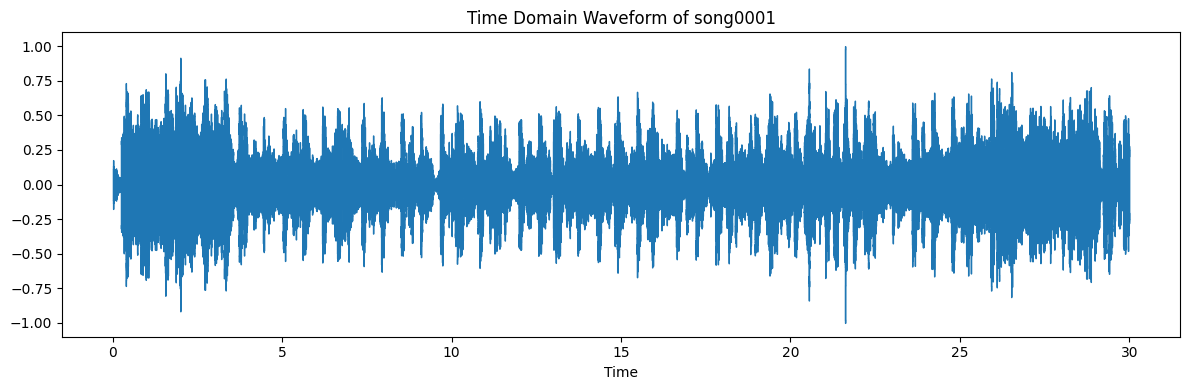

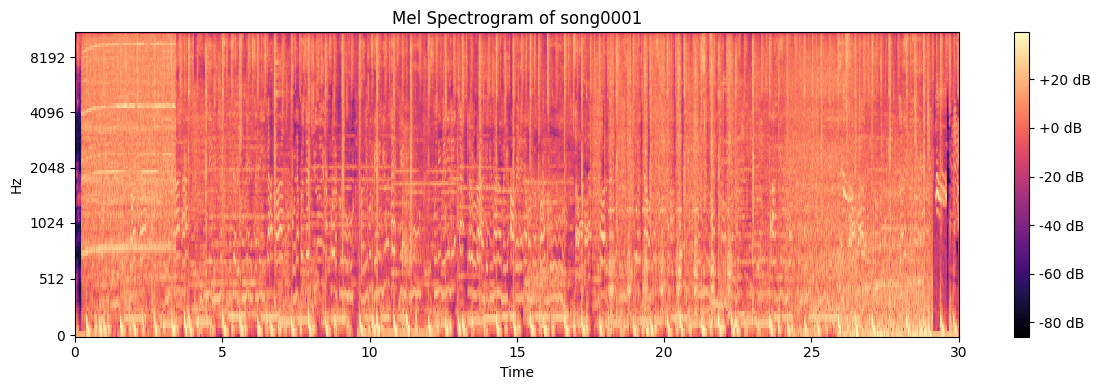

In [45]:
song_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups/song0001.wav'
y, sr = torchaudio.load(song_path)
dur = librosa.get_duration(y=y, sr=sr)
print(f"The number of channels of test audio is {y.shape[0]}")
print(f"The sampling rate of test audio data is: {sr} Hz")
print(f"The duration of test audio data is: {dur} sec")
plot_waveform(y,sr,'song0001')
plot_spectrogram(y,sr,'song0001')

The number of channels of drums audio is 2
The sampling rate of drums audio is: 44100 Hz
The duration of drums audio is: 30.00018140589569 sec


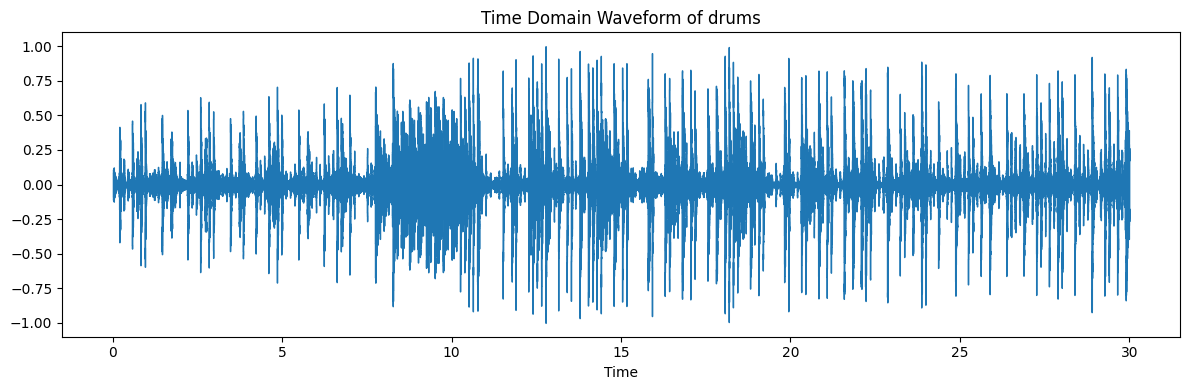

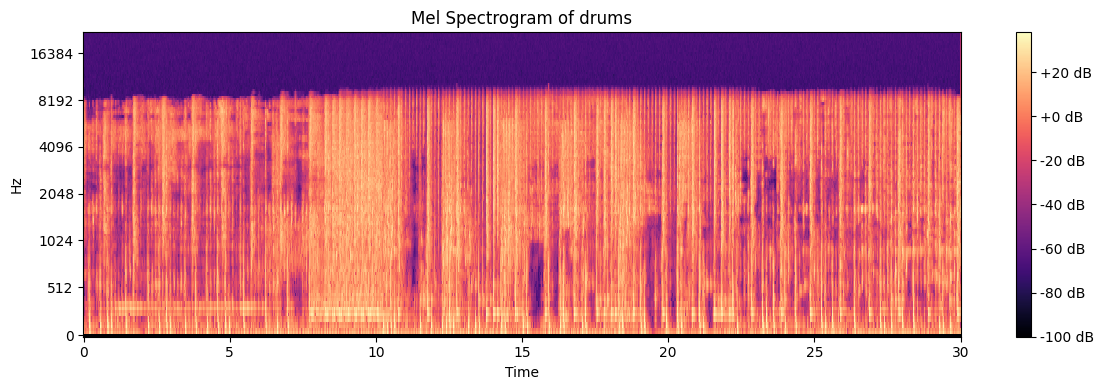



The number of channels of vocals audio is 2
The sampling rate of vocals audio is: 44100 Hz
The duration of vocals audio is: 30.00018140589569 sec


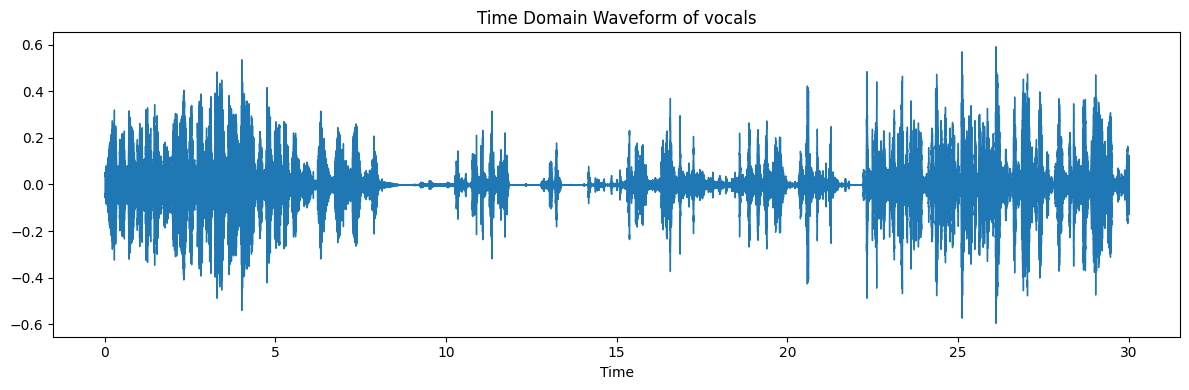

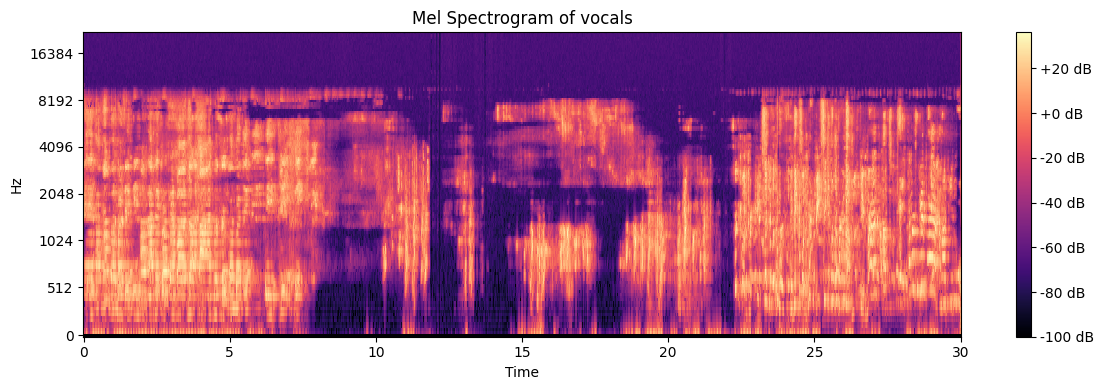



The number of channels of bass audio is 2
The sampling rate of bass audio is: 44100 Hz
The duration of bass audio is: 30.00018140589569 sec


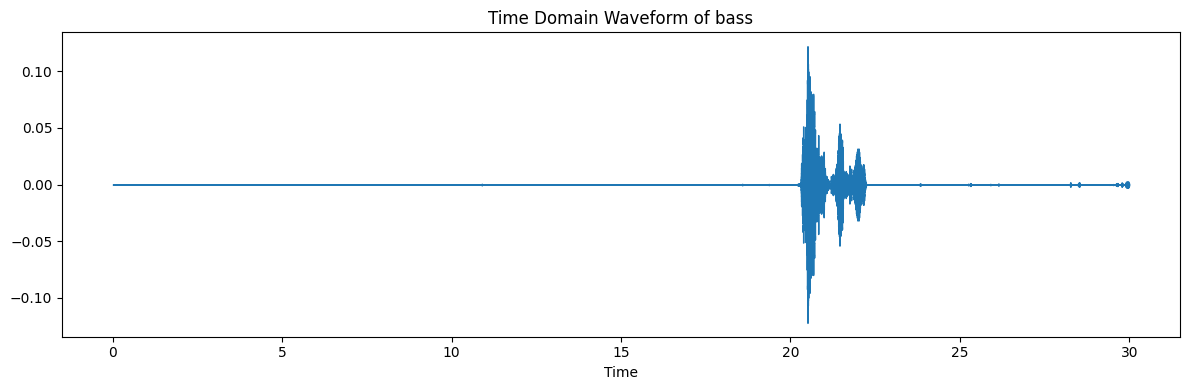

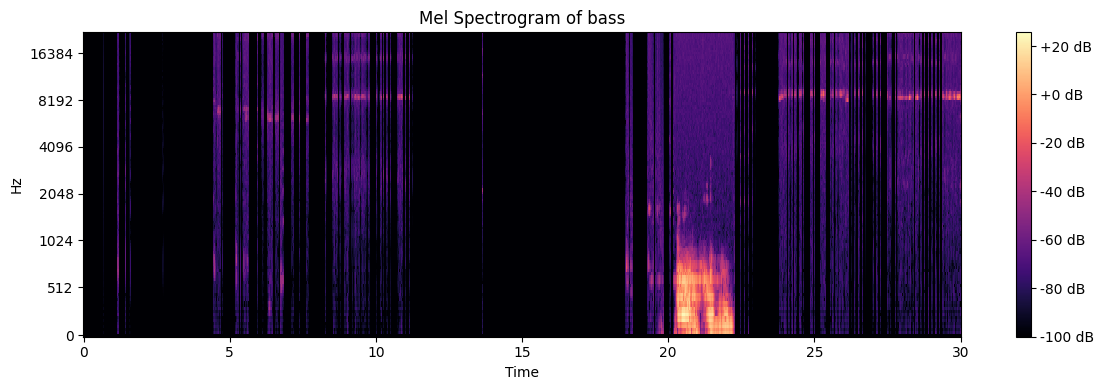



The number of channels of other audio is 2
The sampling rate of other audio is: 44100 Hz
The duration of other audio is: 30.00018140589569 sec


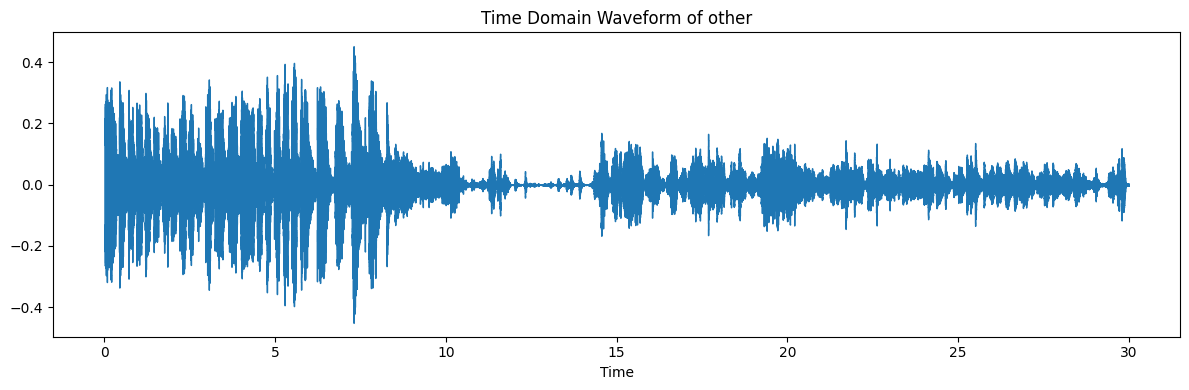

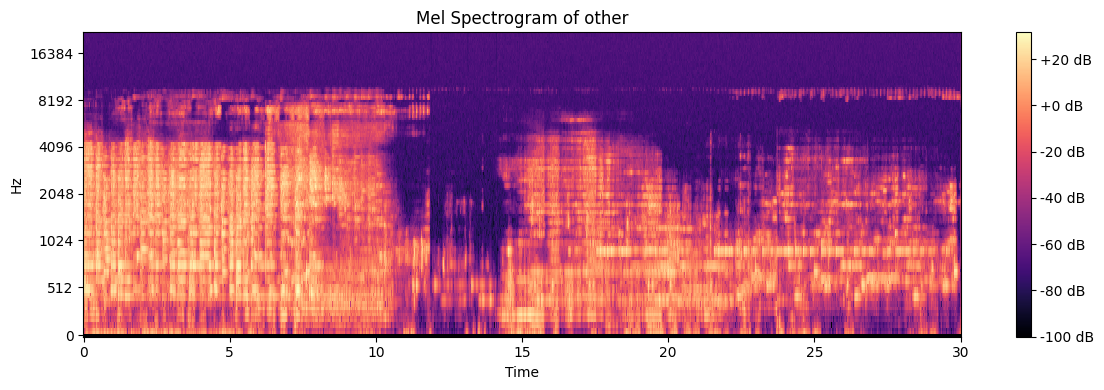

In [46]:
stem_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/hiphop/hiphop.00000/**.wav'
stems_path = glob.glob(stem_path, recursive=True)
for stem in stems_path:
    y, sr = torchaudio.load(stem)
    dur = librosa.get_duration(y=y, sr=sr)
    stem = stem.replace('.wav','')
    stem = stem.split('/')[-1]
    print(f"The number of channels of {stem} audio is {y.shape[0]}")
    print(f"The sampling rate of {stem} audio is: {sr} Hz")
    print(f"The duration of {stem} audio is: {dur} sec")
    plot_waveform(y,sr,stem)
    plot_spectrogram(y,sr,stem)
    print("\n","="*100,"\n")

The number of channels of drums audio is 2
The sampling rate of drums audio is: 44100 Hz
The duration of drums audio is: 30.013333333333332 sec


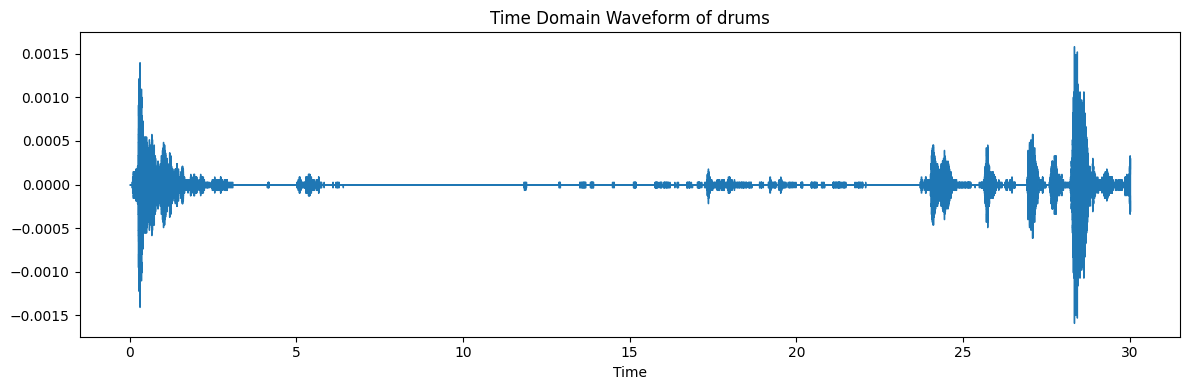

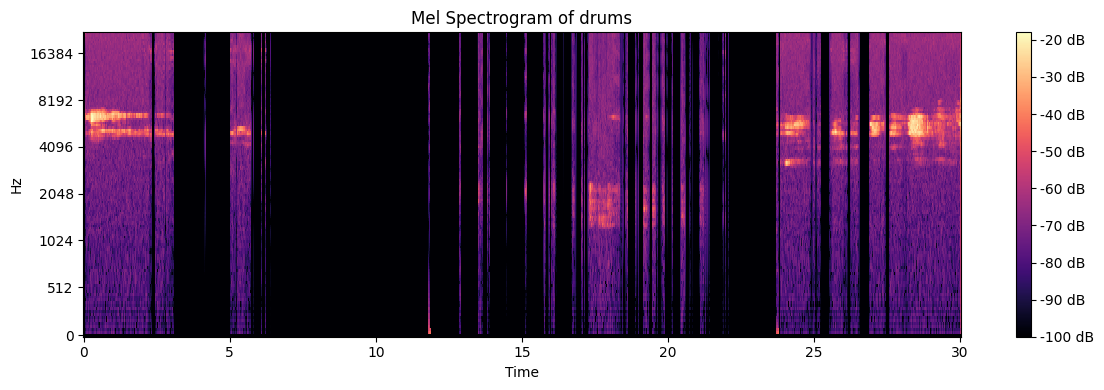



The number of channels of vocals audio is 2
The sampling rate of vocals audio is: 44100 Hz
The duration of vocals audio is: 30.013333333333332 sec


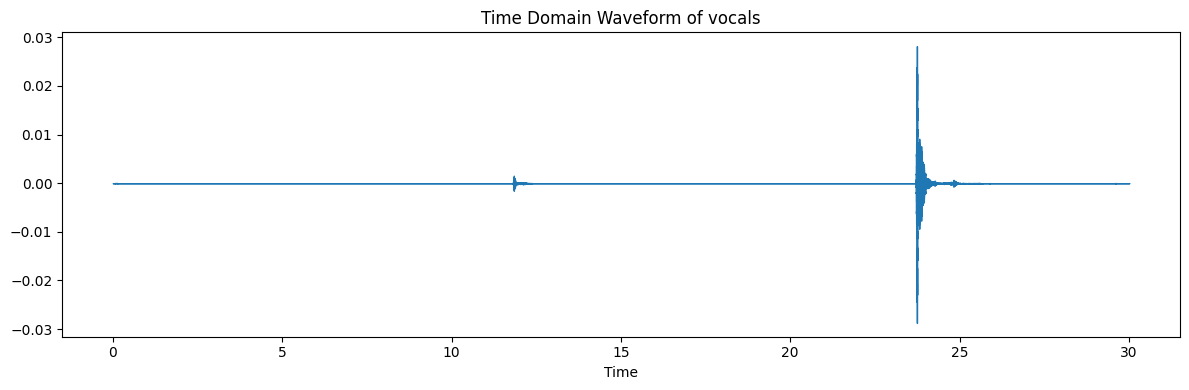

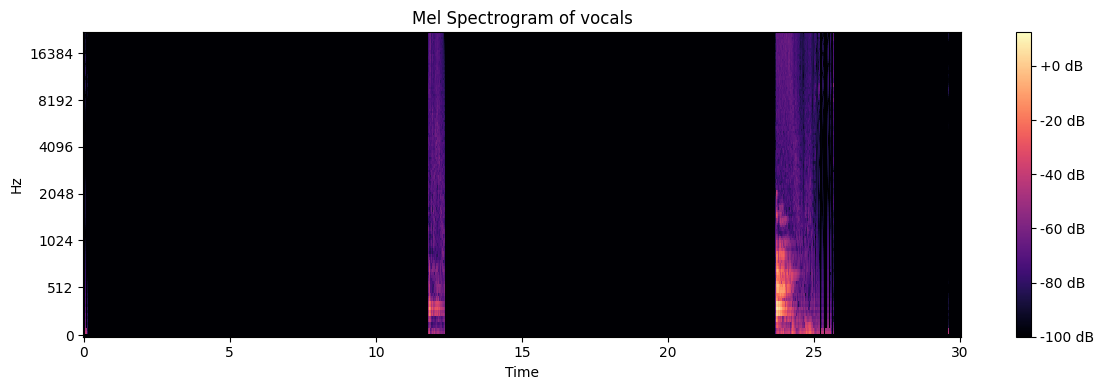



The number of channels of bass audio is 2
The sampling rate of bass audio is: 44100 Hz
The duration of bass audio is: 30.013333333333332 sec


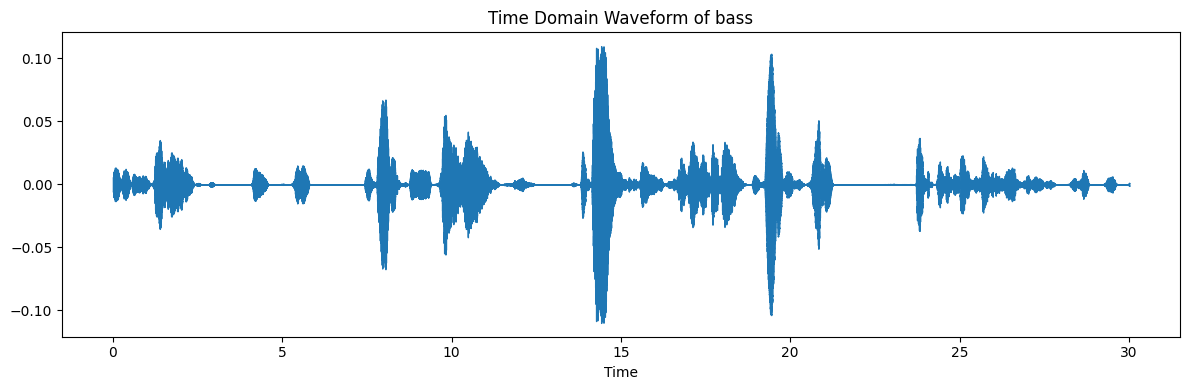

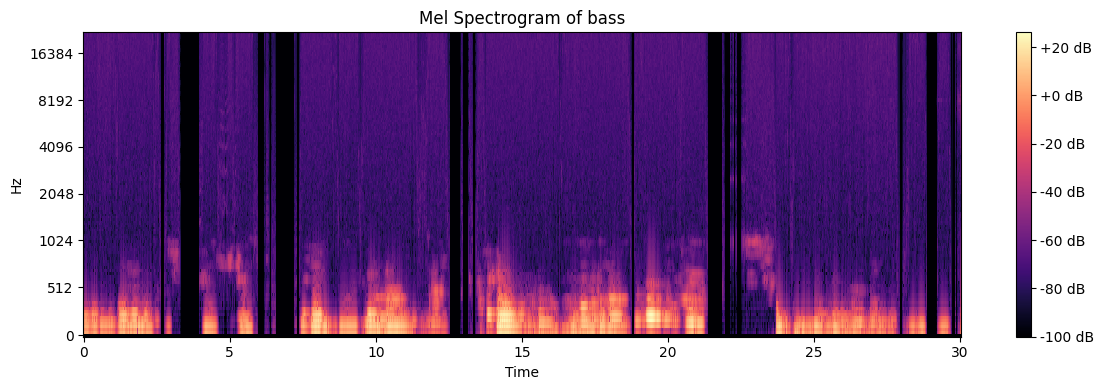



The number of channels of other audio is 2
The sampling rate of other audio is: 44100 Hz
The duration of other audio is: 30.013333333333332 sec


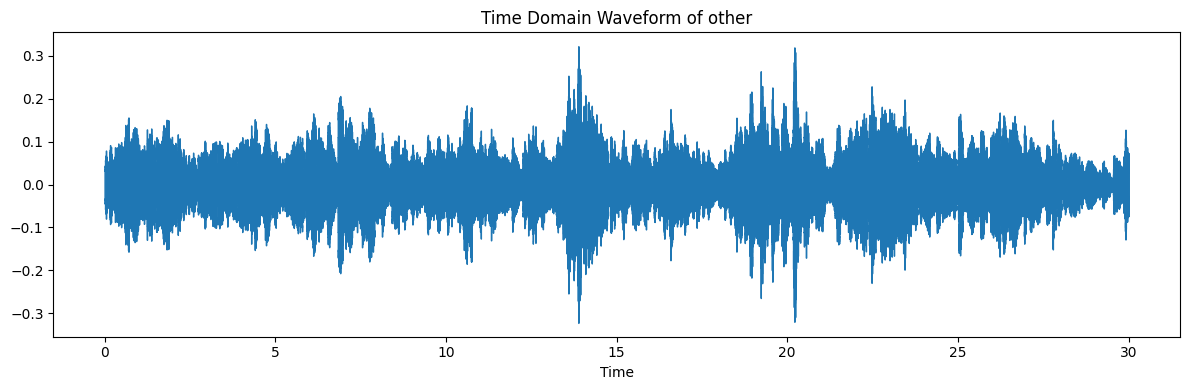

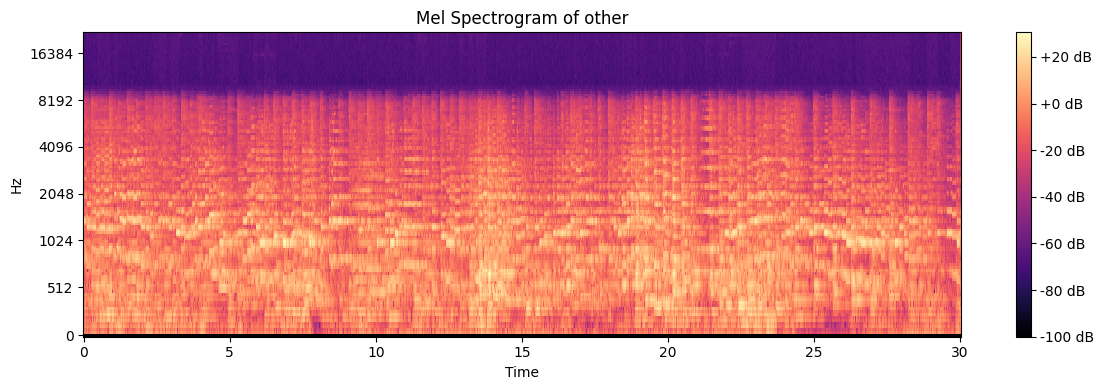

In [47]:
stem_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/classical/classical.00000/**.wav'
stems_path = glob.glob(stem_path, recursive=True)
for stem in stems_path:
    y, sr = torchaudio.load(stem)
    dur = librosa.get_duration(y=y, sr=sr)
    stem = stem.replace('.wav','')
    stem = stem.split('/')[-1]
    print(f"The number of channels of {stem} audio is {y.shape[0]}")
    print(f"The sampling rate of {stem} audio is: {sr} Hz")
    print(f"The duration of {stem} audio is: {dur} sec")
    plot_waveform(y,sr,stem)
    plot_spectrogram(y,sr,stem)
    print("\n","="*100,"\n")

## Messy Mashup Data Generation

### Based on the decided values from the above silence check, we filter the stems

In [48]:
def filter_data(stems_path, noise_path):
    valid_songs = {g: [] for g in GENRES}
    db_value=20
    print(f"Filtering only the uncorrupted songs that contains atleast 2 stems with less than 10 secs of silence i.e., less than {db_value} dB of loudness")
    
    for genre in GENRES:
        songs = glob.glob(os.path.join(stems_path, genre, '*'))
        for song in songs:
            is_valid = True
            valid_count = 0
            for stem in STEMS.values():
                p = os.path.join(song, stem)
                # A file with size less 4kb is treated as a corrupted file 
                if os.path.getsize(p) < 4*1024:
                    is_valid = False
                    break

                y, sr = torchaudio.load(p)
                total_dur = librosa.get_duration(y=y, sr=sr)
                # Extracting all the non-silent durations
                intervals = librosa.effects.split(y, top_db=db_value)
                # Converting the audio tensor to time domain information
                intervals_time = librosa.samples_to_time(intervals, sr=sr)
                non_silent_duration=0
                # Accumulating all the non-silent durations
                for start,end in intervals_time:
                    non_silent_duration=non_silent_duration+(end-start)

                if non_silent_duration >= 20:
                    valid_count += 1
                    
            if is_valid and valid_count >= 2: 
                valid_songs[genre].append(song)

    print("Number of valid songs in each genre: \n")
    for stem in valid_songs:
        print(stem,len(valid_songs[stem]))
            
    raw_noise = glob.glob(os.path.join(noise_path, '**', '*.wav'), recursive=True)
    valid_noise = [n for n in raw_noise if os.path.getsize(n) > 1000]
    
    print(f"Number of valid noise files: {len(valid_noise)}")
    return valid_songs, valid_noise

### Creating train and validation data split with the filtered valid stems

In [49]:
def split_train_val_data(valid_songs):
    print("Splitting raw song folders")
    train_songs = {g: [] for g in GENRES}
    val_songs = {g: [] for g in GENRES}
    
    all_songs = []
    all_genres = []
    
    for genre in GENRES:
        for song in valid_songs[genre]:
            all_songs.append(song)
            all_genres.append(genre)
            
    X_train, X_val, y_train, y_val = train_test_split(
        all_songs, 
        all_genres, 
        test_size=0.2, 
        random_state=42, 
        stratify=all_genres
    )
    
    for song, genre in zip(X_train, y_train):
        train_songs[genre].append(song)
        
    for song, genre in zip(X_val, y_val):
        val_songs[genre].append(song)

    # Getting the maximum count of songs with valid stems comparing across all the genres
    max_train = max(len(songs) for songs in train_songs.values())
    max_val = max(len(songs) for songs in val_songs.values())

    # Picking songs at random with replacment to match the above maximum count
    for genre in GENRES:
        if len(train_songs[genre]) > 0:
            train_songs[genre] = random.choices(train_songs[genre], k=max_train)
        if len(val_songs[genre]) > 0:
            val_songs[genre] = random.choices(val_songs[genre], k=max_val)
        
    return train_songs, val_songs

### Final mashup audio creation with tempo synchronization and truncation

In [50]:
def create_mashup_audio(base_stems, noise_path=None, sync_tempo=True):
    print("Create mashups tempo-synced to the drum track and padding the mixes.")
    loaded_stems = {}
    
    for stem_name, path in base_stems.items():
        y, sr = torchaudio.load(path)
        # Resampling the stems to match the SR of 16KHz
        if sr != SR:
            resampler = torchaudio.transforms.Resample(sr, SR)
            y = resampler(y)
        # Converting the 2 channel stereo track into a single channel mono track by taking the mean of the two channels
        if y.shape[0] > 1:
            y = y.mean(dim=0, keepdim=True)
        # Stripping the channel to keep only the Freq and Time
        loaded_stems[stem_name] = y.squeeze(0).numpy()

    # Base numpy array of zero created to match the traget sample output
    mix = np.zeros(TARGET_SAMPLES)
    master_tempo = 0

    # For creating mashups with stems from different songs, the tempo synchronization is must to make it sound rhythmic, else it will sound like a distorted audio or noise
    if sync_tempo:
        drum_track = loaded_stems.get('drums', loaded_stems['vocals'])
        master_tempo, _ = librosa.beat.beat_track(y=drum_track, sr=SR)
        master_tempo = float(master_tempo)
    
    for stem_name, y in loaded_stems.items():
        # Apply time stretching only if it's not the master track and  tempo (bpm) > 0
        if sync_tempo and stem_name != 'drums' and master_tempo > 0:
            stem_tempo, _ = librosa.beat.beat_track(y=y, sr=SR)
            stem_tempo = float(stem_tempo)
            if stem_tempo > 0:
                # Prevent distortion of audio to extreme tempo by limit the speed between 0.7 and 1.3
                rate = np.clip(master_tempo / stem_tempo, 0.7, 1.3)
                y = librosa.effects.time_stretch(y, rate=rate)
        
        # Truncate the longer audio to match the target output samples
        if len(y) > TARGET_SAMPLES:
            y = y[:TARGET_SAMPLES] 
        else:
        # Pad the shorter audio to match the target output samples
            y = np.pad(y, (0, TARGET_SAMPLES - len(y)))
        mix += y
        
    # Applying the same preprocessing steps as above on the noise clips also
    if noise_path:
        n_wave, sr = torchaudio.load(noise_path)

        if sr != SR:
            resampler = torchaudio.transforms.Resample(sr, SR)
            n_wave = resampler(n_wave)        
        if n_wave.shape[0] > 1: 
            n_wave = n_wave.mean(dim=0, keepdim=True)
        n_wave = n_wave.squeeze(0).numpy()
        
        if len(n_wave) > TARGET_SAMPLES:
            n_wave = n_wave[:TARGET_SAMPLES] 
        else:
            n_wave = np.pad(n_wave, (0, TARGET_SAMPLES - len(n_wave)))

        # The preprocessed noise clip volume is cut down to a random value between 10% and 40% before mixing
        mix += (n_wave * random.uniform(0.1, 0.4))
        
    # Peak - Normalization to scale the audio between -1 and 1
    mix = mix / (np.max(np.abs(mix)))
    return torch.tensor(mix, dtype=torch.float32).unsqueeze(0)

### Training and Validation datasets creation with pitch augmentation 

In [51]:
def build_dataset(valid_songs, valid_noise, target_dir, samples_per_set):
    print("Building 5 variations of Mashup Dataset")
    os.makedirs(target_dir, exist_ok=True)
    generated_files = []
    
    for genre in tqdm(GENRES, desc=f"Processing Genres"):
        genre_out = os.path.join(target_dir, genre)
        os.makedirs(genre_out, exist_ok=True)
        songs = valid_songs[genre]
        
        file_idx = 0
            
        for i in range(samples_per_set):
            base_song = random.choice(songs)
            base_stems = {s: os.path.join(base_song, STEMS[s]) for s in STEMS.keys()}

            if len(base_stems) < 4: continue

            # Helper function to save the mashups
            def save_audio_mix(mix_tensor, genre_label, out_path, idx, set_id):
                filename = f"{idx:03d}.wav"
                full_path = os.path.join(out_path, filename)
                torchaudio.save(full_path, mix_tensor, SR)
                return {'path': full_path, 'genre': genre_label, 'set_id': set_id}

            # Variation 1: Mashup with stems from same song, since it is the same song sync_tempo is set to False
            mix1 = create_mashup_audio(base_stems, noise_path=None, sync_tempo=False)
            generated_files.append(save_audio_mix(mix1, genre, genre_out, file_idx, set_id=1))
            file_idx += 1
            
            # Variation 2: Mashup with stems from same song with noise, since it is the same song sync_tempo is set to False
            mix2 = create_mashup_audio(base_stems, noise_path=random.choice(valid_noise), sync_tempo=False)
            generated_files.append(save_audio_mix(mix2, genre, genre_out, file_idx, set_id=2))
            file_idx += 1
            
            # Variation 3: Mashup with stems from different songs of same genre
            s3_songs = random.sample(songs, 4)
            s3_stems={}
            idx=0
            for stem in STEMS.keys():
                s3_stems[stem] = os.path.join(s3_songs[idx], STEMS[stem])
                idx+=1       
            # s3_stems = { 'drums': os.path.join(s3_songs[0], 'drums.wav'), 'bass.wav': os.path.join(s3_songs[1], 'bass.wav'),
            #              'vocals': os.path.join(s3_songs[2], 'vocals.wav'), 'other.wav': os.path.join(s3_songs[3], 'other.wav')}
            mix3 = create_mashup_audio(s3_stems, noise_path=None, sync_tempo=True)
            generated_files.append(save_audio_mix(mix3, genre, genre_out, file_idx, set_id=3))
            file_idx += 1

            # Variation 4: Mashup with stems from different songs of same genre with noise and pitch augmentation
            mix4 = create_mashup_audio(s3_stems, noise_path=random.choice(valid_noise), sync_tempo=True)
            # The pitch augmentation is done for 40% of the created mashups, varing the pitch shifts from -2 to +2 at random, again
            if random.random() < 0.4 and 'train' in target_dir:
                n_steps = random.choice([-2, -1, 1, 2])
                mix4 = F_audio.pitch_shift(mix4, SR, n_steps)
            generated_files.append(save_audio_mix(mix4, genre, genre_out, file_idx, set_id=4))
            file_idx += 1

            # Variation 5: Mashup of stems from different songs of same genre and drums and other stems from songs from different genre with noise and pitch augmentation 
            s5_songs = random.sample(songs, 2)
            cross_g = random.sample([g for g in GENRES if g != genre], 2)
            s5_stems = {
                'vocals': os.path.join(s5_songs[0], 'vocals.wav'),
                'bass': os.path.join(s5_songs[1], 'bass.wav'),
                'drums': os.path.join(random.choice(valid_songs[cross_g[0]]), 'drums.wav'),
                'other': os.path.join(random.choice(valid_songs[cross_g[1]]), 'other.wav')
            }
            mix5 = create_mashup_audio(s5_stems, noise_path=random.choice(valid_noise), sync_tempo=True)
            # The pitch augmentation is done for 40% of the created mashups, varing the pitch shifts from -2 to +2 at random, again
            if random.random() < 0.4 and 'train' in target_dir:
                n_steps = random.choice([-2, -1, 1, 2])
                mix5 = F_audio.pitch_shift(mix5, SR, n_steps)
            generated_files.append(save_audio(mix5, genre, genre_out, file_idx, set_id=5))
            file_idx += 1
            
    return generated_files

### Dataset generation or retrieval for training and validation

In [52]:
def retrieve_or_generate_data(use_new_data=None):

    if use_new_data is True:
        SAVED_FILES_TRAIN_PATH = '/kaggle/input/datasets/gokulvasudevans/synthetic-mashups-pitch-aug-2/synthetic_mashups_pitch_aug_2/synthetic_mashups/train/**/*.wav'
        SAVED_FILES_VAL_PATH = '/kaggle/input/datasets/gokulvasudevans/synthetic-mashups-pitch-aug-2/synthetic_mashups_pitch_aug_2/synthetic_mashups/val/**/*.wav'
        print("Training using the new dataset")
    elif use_new_data is False:
        SAVED_FILES_TRAIN_PATH = '/kaggle/input/datasets/gokulvasudevans/synthetic-mashups-pitch-aug/synthetic_mashups/train/**/*.wav'
        SAVED_FILES_VAL_PATH = '/kaggle/input/datasets/gokulvasudevans/synthetic-mashups-pitch-aug/synthetic_mashups/val/**/*.wav'
        print("Training using the old dataset")
    elif use_new_data is None:
        print("Generating new files for training")
    
    saved_train_files = glob.glob(SAVED_FILES_TRAIN_PATH, recursive=True)
    train_files = []

    saved_val_files = glob.glob(SAVED_FILES_VAL_PATH, recursive=True)
    val_files = []

    if use_new_data is not None and len(saved_train_files) > 0 and len(saved_val_files) > 0:
        print(f"Retrieving {len(saved_train_files)} train and {len(saved_val_files)} validation mashup files ")
        for path in saved_train_files:
            genre = path.split('/')[-2]
            filename = os.path.basename(path)
            idx = int(filename.replace('.wav', '').replace('mashup_', ''))
            set_id = (idx % 5) + 1 # From creation, we know that 0=Set1, 1=Set2, 2=Set3, 3=Set4, 4=Set5, 5=Set1...
                
            train_files.append({'path': path, 'genre': genre, 'set_id': set_id})

        for path in saved_val_files:
            genre = path.split('/')[-2]
            filename = os.path.basename(path)
            idx = int(filename.replace('.wav', '').replace('mashup_', ''))
            set_id = (idx % 5) + 1 # From creation, we know that 0=Set1, 1=Set2, 2=Set3, 3=Set4, 4=Set5, 5=Set1...
                
            val_files.append({'path': path, 'genre': genre, 'set_id': set_id})
    else:
        valid_songs, valid_noise = filter_data(STEMS_PATH, NOISE_PATH)
        train_songs, val_songs = split_train_val_data(valid_songs)
        train_files = build_dataset(train_songs, valid_noise, SYNTHETIC_TRAIN_DIR, samples_per_set=100)
        val_files = build_dataset(val_songs, valid_noise, SYNTHETIC_VAL_DIR, samples_per_set=25)
        
    print(f"Training Samples: {len(train_files)}")
    print(f"Validation Samples: {len(val_files)}")
    
    return train_files, val_files

### Generalized Dataset Loader for all the models to extract the final spec, incorporated with on-the-fly spec augmentation

In [53]:
class MessyMashupDatasetLoader(Dataset):
    def __init__(self, file_list, mode='ast', is_Train=False):
        self.file_list = file_list
        self.mode = mode
        self.is_train = is_Train
        self.mel_spec = T.MelSpectrogram(sample_rate=SR, n_fft=1024, hop_length=512, n_mels=128)
        self.to_db = T.AmplitudeToDB()
        self.augmenter = nn.Sequential(
            T.FrequencyMasking(freq_mask_param=20), # 20/128 = 0.15625 - 15.62% of the audio frequency bands are masked
            T.TimeMasking(time_mask_param=40) # 40/313 = 0.12779 - 12.78% of the audio time bands are masked
        ) if is_Train else None

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = self.file_list[idx]['path']
        label = GENRE_TO_IDX[self.file_list[idx]['genre']]

        wave, _ = torchaudio.load(path)

        if self.is_train:
            # Apply Random Gain (Volume shift between 0.5x and 1.5x)
            gain = random.uniform(0.5, 1.5)
            wave = wave * gain
            
            # Ensure it doesn't clip past -1.0 or 1.0
            wave = torch.clip(wave, -1.0, 1.0)
        
        if self.mode in ['cnn', 'crnn']:
            # Mel Transform output shape - [Channel, Freq, Time] - [1, 128, 313]
            spec = self.to_db(self.mel_spec(wave))

            if self.is_train:
                spec = self.augmenter(spec)
        else:
            ast_extractor = get_ast_extractor()
            # AST Extractor expects 1D numpy array in shape - [Time, Freq] - [313, 128]
            inputs = ast_extractor(wave.squeeze(0).numpy(), sampling_rate=SR, return_tensors="pt")
            spec = inputs['input_values'].squeeze(0)
            
            if self.is_train:
                # Add fake channel [1, Freq, Time] for Torchaudio
                spec = spec.transpose(0, 1).unsqueeze(0)
                spec = self.augmenter(spec)
                # Strip fake channel and flip back to [Time, Freq] for AST
                spec = spec.squeeze(0).transpose(0, 1)
                
        return spec, label

### Custom DataLoader to load the specs based on the batch size requirement of the models for parallel computations

In [54]:
def custom_data_loader(model_name, batch_size, use_new_data=False):
    train_files, val_files = retrieve_or_generate_data(use_new_data)
    
    y, sr = torchaudio.load(train_files[0]['path'])
    plot_waveform(y, sr, train_files[0]['genre'])
    plot_spectrogram(y, sr, train_files[0]['genre'])
    
    y, sr = torchaudio.load(val_files[0]['path'])
    plot_waveform(y, sr, train_files[0]['genre'])
    plot_spectrogram(y, sr, val_files[0]['genre'])

    num_cpus = multiprocessing.cpu_count()
    num_workers = max(1, num_cpus - 1)
   
    train_loader = DataLoader(MessyMashupDatasetLoader(train_files, model_name, True), batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(MessyMashupDatasetLoader(val_files, model_name, False), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    data_batch, label_batch = next(iter(val_loader))
    
    print(f"Batch Data Shape: {data_batch.shape}")
    print(f"Batch Labels: {label_batch}")
    
    single_file = data_batch[0]
    single_label = label_batch[0]
    
    print(f"Shape: {single_file.shape}")
    print(f"Genre Name: {IDX_TO_GENRE[single_label.item()]}")

    return train_loader, val_loader

## Custom Helper Classes

### Focal Loss, implemented to experiment against the Cross Entropy

In [55]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1):
        super(FocalLoss, self).__init__()
        # gamma=2.0 is the industry standard for Focal Loss. 
        # It dictates how aggressively the loss drops for "easy" examples.
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # Calculate the probabilities for all classes using Softmax from the raw logits
        probs = F.softmax(logits, dim=-1)
        
        # Extract the predicted probabilities of the *actual* correct target classes (p_t)
        target_probs = probs.gather(dim=-1, index=targets.view(-1, 1)).view(-1)
        
        # Calculate the standard Cross Entropy Loss with your label smoothing
        # We set reduction='none' so we can apply the focal weight to each batch item individually
        cross_entropy_loss = F.cross_entropy(
            logits, 
            targets, 
            label_smoothing=self.label_smoothing, 
            reduction='none'
        )
        
        # Apply the Focal multiplier
        focal_weight = (1 - target_probs) ** self.gamma
        
        # Multiply and return the average loss for the batch
        focal_loss = focal_weight * cross_entropy_loss
        return focal_loss.mean()

### Early Stopping, implemented to save the best model with the maximum F1 score

In [56]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.counter = 0
        self.best_f1_score = 0
        self.early_stop = False

    def __call__(self, val_f1_score):
        if val_f1_score > self.best_f1_score:
            self.best_f1_score = val_f1_score
            self.counter = 0
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

## Model Architectures

### SOTA Audio Spectrogram Transformer

In [57]:
def get_ast_extractor():
    return AutoFeatureExtractor.from_pretrained(AST_VER)

def get_ast_model():
    return ASTForAudioClassification.from_pretrained(
        AST_VER, 
        num_labels=10, 
        ignore_mismatched_sizes=True
    )

### CNN based EfficientNet

In [58]:
class EfficientNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.efnet = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V2)
        
        orig_conv = self.efnet.features[0][0]
        new_conv = nn.Conv2d(in_channels=1, # Tweaking the input channels of the model to accept 1-Channel Mel spectrogram instead of a 3-Channel RGB image
                             out_channels=orig_conv.out_channels, 
                             kernel_size=orig_conv.kernel_size, 
                             stride=orig_conv.stride, 
                             padding=orig_conv.padding, 
                             bias=False)

        with torch.no_grad():
            new_conv.weight.data = orig_conv.weight.data.sum(dim=1, keepdim=True)
            
        self.efnet.features[0][0] = new_conv

        in_features=self.efnet.classifier[1].in_features
        self.efnet.classifier[1] = nn.Linear(in_features, num_classes)
        # self.efnet.classifier[1] = nn.Sequential(
        #     nn.Dropout(0.4),
        #     nn.Linear(in_features, num_classes)
        # )
        
    def forward(self, x):
        return self.efnet(x)

### Custom built CRNN

In [59]:
class CRNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Bottleneck is useful to compress the data and also ensures the bidirectional LSTM does not overfit
        self.bottleneck = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        # We use bidirectional LSTM to make the perceive the musical rhythm better
        # batch_first is set to True to force the LSTM to accept [Batch, Time, Features]
        self.lstm = nn.LSTM(512, 128, batch_first=True, bidirectional=True)
        #self.gru = nn.GRU(512, 128, batch_first=True, bidirectional=True)
        
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
            # nn.Linear(512, num_classes) # for max pool + mean pool
        )
        
    def forward(self, x):
        x = self.cnn(x)
        b, c, f, t = x.shape
        x=x.permute(0, 3, 1, 2).reshape(b, t, c * f)
        x = self.bottleneck(x)
        rnn_out, _ = self.lstm(x) #Output shape - [32, 313, 256]
        pooled, _ = torch.max(rnn_out, dim=1) #Output shape - [32, 256]
        # max_pool, _ = torch.max(rnn_out, dim=1)
        # mean_pool = torch.mean(rnn_out, dim=1)
        # pooled = torch.cat([max_pool, mean_pool], dim=1)
        return self.fc(pooled)

## Model Training Pipelines

### Two staged pipeline for AST

In [60]:
def train_ast_pipeline(model_name='ast', use_new_data=False, batch_size=8, phase1_epochs=2, phase2_epochs=5):    
    train_loader, val_loader = custom_data_loader(model_name,batch_size, use_new_data)
    
    model = get_ast_model().to(device)

    # Initialize W&B
    wandb.init(project="21f2000660-dl-gen-ai-project-26-t1", name=f"{model_name}_TwoStage_Run")
    # criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    # criterion = FocalLoss(gamma=2.0, label_smoothing=0.1)
    early_stopper = EarlyStopping(patience=3)
    best_f1 = 0.0

    print("Stage 1: Training only the classifier block")
    
    # Freeze the pre-trained transformer base, leave only the classifier unfrozen
    for param in model.audio_spectrogram_transformer.parameters():
        param.requires_grad = False
        
    # Larger learning rate just for the classifier
    optimizer_1 = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=0.01)
    
    for epoch in range(phase1_epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Phase 1 - Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_1.zero_grad()
            # The AST model when supplied with the output labels alongside the inputs, will return the hard class values as outputs
            # The output also binds a deafult custom loss function based on Cross Entropy, used in AST
            # But if the labels are not sent to the model, then it outputs the logits also
            # This is useful to force a different custom loss function during the training 
            outputs = model(inputs, labels=labels)  # outputs = model(inputs)
            loss = outputs.loss # loss = criterion(outputs.logits, labels)
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
            optimizer_1.step()
            train_loss += loss.item()

        # the model is set to eval for logging the classifier level learning
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                logits = model(inputs.to(device)).logits
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        acc = accuracy_score(all_labels, all_preds)
        current_lr = optimizer_1.param_groups[0]['lr']

        wandb.log({'Epoch': epoch+1, "Train Loss": train_loss/len(train_loader), "Val F1": val_f1, "Val Acc": acc, "LR": current_lr})
        print(f"Phase 1 - Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f} | Val Acc: {acc:.4f} | LR: {current_lr:.6f}")

    print("Stage 2: Full Flegded Training")
    
    # Unfreeze the base
    for param in model.audio_spectrogram_transformer.parameters():
        param.requires_grad = True
        
    # Smaller learning rate for the whole model, with weight decay to prevent overfitting
    optimizer_2 = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
    
    # Cosine Scheduler: Warms up for 10% of steps, then gently decays
    total_steps = len(train_loader) * phase2_epochs
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_cosine_schedule_with_warmup(optimizer_2, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    for epoch in range(phase2_epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Phase 2 - Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_2.zero_grad()
            outputs = model(inputs, labels=labels)  # outputs = model(inputs)
            loss = outputs.loss # loss = criterion(outputs.logits, labels)
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_2.step()
            scheduler.step()
            train_loss += loss.item()
            
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                logits = model(inputs.to(device)).logits
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        acc = accuracy_score(all_labels, all_preds)
        current_lr = optimizer_2.param_groups[0]['lr']
        
        wandb.log({'Epoch': epoch+1+phase1_epochs, "Train Loss": train_loss/len(train_loader), "Val F1": val_f1, "Val Acc": acc, "LR": current_lr})
        print(f"Phase 2 - Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f} | Val Acc: {acc:.4f} | LR: {current_lr:.6f}")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "/kaggle/working/best_ast_twostage.pth")
            print("New best model using two stage training pipeline saved")

        early_stopper(val_f1)
        if early_stopper.early_stop:
            print("Early stopping triggered in Phase 2.")
            break
            
    wandb.finish()
    plot_confusion_matrix(all_labels, all_preds, f'{model_name}_{epoch+1}')
    return "/kaggle/working/best_ast_twostage.pth"

### Two staged pipeline for CNN

In [61]:
def train_cnn_pipeline(model_name='cnn', use_new_data=False, batch_size=32, epochs=25):    
    train_loader, val_loader = custom_data_loader(model_name,batch_size, use_new_data)

    phase1_epochs = 0
    model = EfficientNet().to(device)    
    
    # Initialize W&B
    wandb.init(project="21f2000660-dl-gen-ai-project-26-t1", name=f"{model_name}_training_run")
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    # criterion = FocalLoss(gamma=2.0, label_smoothing=0.1)
    early_stopper = EarlyStopping(patience=8)
    best_f1 = 0.0
    
    print("Phase 1: Training only the classifier block")

    for param in model.efnet.features.parameters():
        param.requires_grad = False

    for param in model.efnet.classifier.parameters():
        param.requires_grad = True
        
    optimizer_1 = optim.AdamW(model.efnet.classifier.parameters(), lr=0.001, weight_decay=0.01)

    for epoch in range(phase1_epochs):
        # Training Phase
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Phase 1 - Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_1.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer_1.step()
            train_loss += loss.item()
            
        # Evaluation Phase
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')
        acc = accuracy_score(all_labels, all_preds)
        current_lr = optimizer_1.param_groups[0]['lr']

        wandb.log({'Epoch': epoch+1, "Train Loss": train_loss/len(train_loader), "Val F1": val_f1, "Val Acc": acc, "LR": current_lr})
        print(f"Phase 1 - Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f} | Val Acc: {acc:.4f} | LR: {current_lr:.6f}")
  
    print("Phase 2: Full Flegded Training")

    for param in model.efnet.features.parameters():
        param.requires_grad = True

    optimizer_2 = optim.AdamW(model.efnet.parameters(), lr=0.0001, weight_decay=0.01)

    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='max',factor=0.2,patience=3,threshold=1e-3)
    total_steps = len(train_loader) * (epochs-phase1_epochs)
    scheduler = get_cosine_schedule_with_warmup(optimizer_2, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)

    for epoch in range(phase1_epochs, epochs):
        # Training Phase
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Phase 2 - Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_2.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer_2.step()
            scheduler.step()
            train_loss += loss.item()
            
        # Evaluation Phase
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        # Metrics       
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        acc = accuracy_score(all_labels, all_preds)       
        current_lr = optimizer_2.param_groups[0]['lr']
        
        wandb.log({'Epoch': epoch+1, "Train Loss": train_loss/len(train_loader), "Val F1": val_f1, "Val Acc": acc, "LR": current_lr})
        print(f"Phase 2 - Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f} | Val Acc: {acc:.4f} | LR: {current_lr:.6f}")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), f"/kaggle/working/best_{model_name}.pth")
            print(f"New best model saved")

        early_stopper(val_f1)
        if early_stopper.early_stop:
            print("Early stopping triggered")
            break
            
    wandb.finish()
    plot_confusion_matrix(all_labels, all_preds, f'{model_name}_{epoch+1+phase1_epochs}')
    return f"/kaggle/working/best_{model_name}.pth"

### Simple pipeline for CRNN

In [62]:
def train_crnn_pipeline(model_name='crnn', use_new_data=False, batch_size=32, epochs=25):    
    train_loader, val_loader = custom_data_loader(model_name,batch_size,use_new_data)
    
    model = CRNN().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01)
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    # criterion = FocalLoss(gamma=2.0, label_smoothing=0.1)

    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='max',factor=0.2,patience=3,threshold=1e-3)
    total_steps = len(train_loader) * epochs
    scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
    
    # Initialize W&B
    wandb.init(project="21f2000660-dl-gen-ai-project-26-t1", name=f"{model_name}_training_run")
    early_stopper = EarlyStopping(patience=8)
    best_f1 = 0.0

    for epoch in range(epochs):      
        # Training Phase
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()           
            loss = criterion(model(inputs), labels)
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
            
        # Evaluation Phase
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        # Metrics       
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        acc = accuracy_score(all_labels, all_preds)       
        current_lr = optimizer.param_groups[0]['lr']
        
        wandb.log({'Epoch': epoch+1, "Train Loss": train_loss/len(train_loader), "Val F1": val_f1, "Val Acc": acc, "LR": current_lr})
        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f} | Val Acc: {acc:.4f} | LR: {current_lr:.6f}")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), f"/kaggle/working/best_{model_name}.pth")
            print(f"New best model saved")

        early_stopper(val_f1)
        if early_stopper.early_stop:
            print(f"Early stopping triggered.")
            break
            
    wandb.finish()
    plot_confusion_matrix(all_labels, all_preds, f'{model_name}_{epoch+1}')
    return f"/kaggle/working/best_{model_name}.pth"

## Initialization of Training and Validation

### Set appropriate variables to pick one of the models for training and inference

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Prediction using the saved best ast model
Training using the old dataset
Retrieving 4000 train and 1000 validation mashup files 
Training Samples: 4000
Validation Samples: 1000


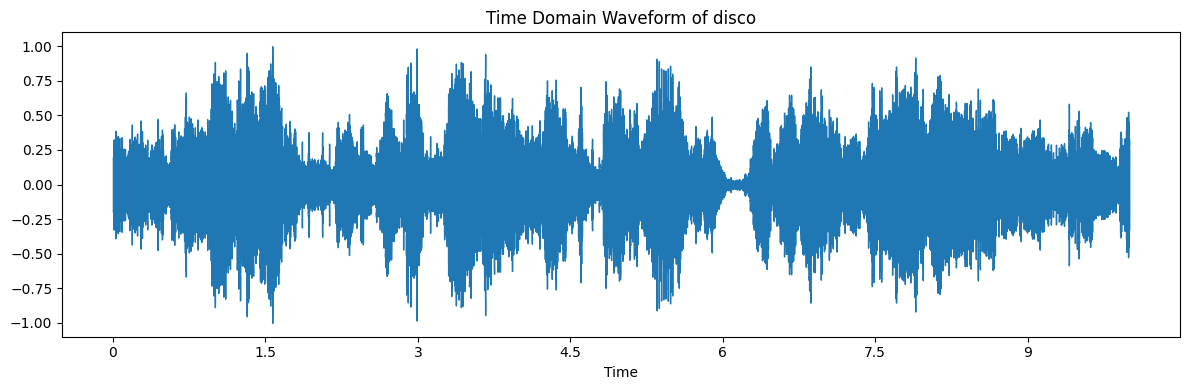

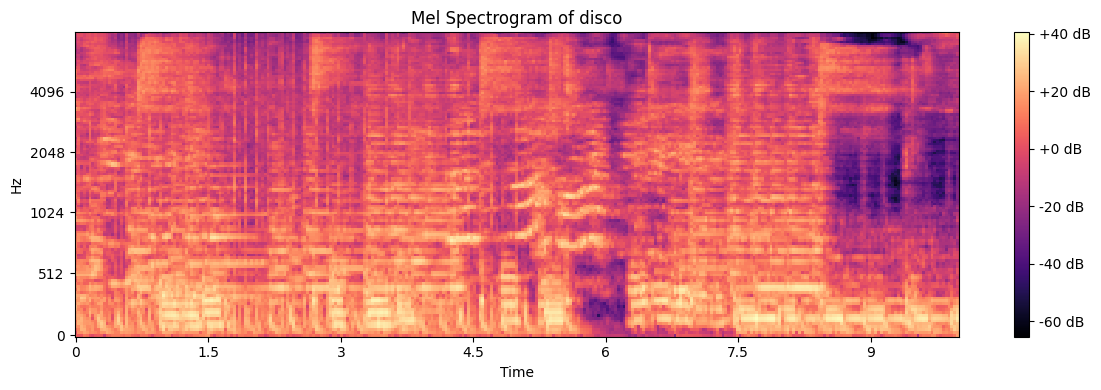

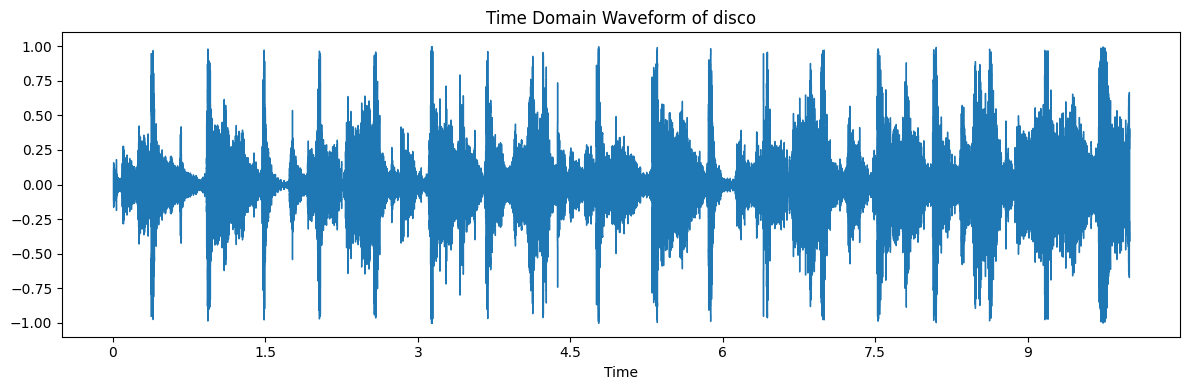

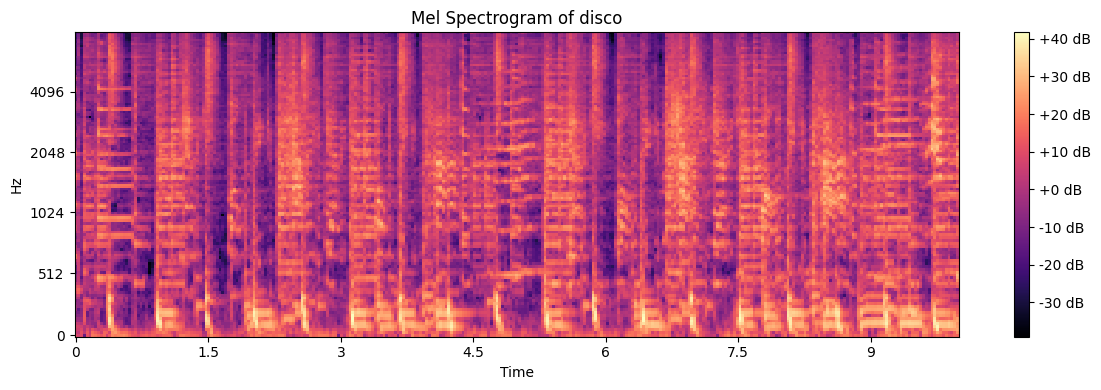

Batch Data Shape: torch.Size([8, 1024, 128])
Batch Labels: tensor([3, 3, 3, 3, 3, 3, 3, 3])
Shape: torch.Size([1024, 128])
Genre Name: disco
              precision    recall  f1-score   support

       blues       0.86      0.74      0.80       100
   classical       0.80      0.92      0.86       100
     country       0.77      0.77      0.77       100
       disco       0.72      0.84      0.78       100
      hiphop       0.92      0.84      0.88       100
        jazz       0.82      0.77      0.79       100
       metal       0.85      0.83      0.84       100
         pop       0.84      0.77      0.80       100
      reggae       0.78      0.87      0.82       100
        rock       0.60      0.58      0.59       100

    accuracy                           0.79      1000
   macro avg       0.80      0.79      0.79      1000
weighted avg       0.80      0.79      0.79      1000



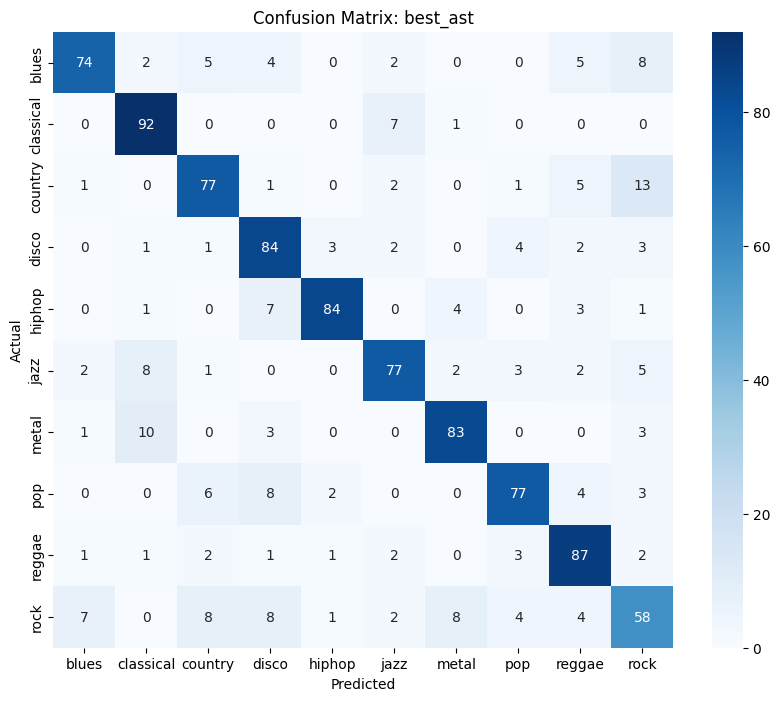



--- TP, TN, FP, FN for all genres  ---
blues 		 74 888 12 26
classical 		 92 877 23 8
country 		 77 877 23 23
disco 		 84 868 32 16
hiphop 		 84 893 7 16
jazz 		 77 883 17 23
metal 		 83 885 15 17
pop 		 77 885 15 23
reggae 		 87 875 25 13
rock 		 58 862 38 42


<Figure size 640x480 with 0 Axes>

In [63]:
CHOSEN_MODEL = 'ast'
use_new_data=False # Set the value to None, for generating new mashup files
use_saved_best_model = True
n_epochs = 30
phase1_epochs = 2
phase2_epochs = 5

if CHOSEN_MODEL == 'ast': 
    model = get_ast_model().to(device)
    batch_size = 8
    if use_saved_best_model:
        print(f"Prediction using the saved best {CHOSEN_MODEL} model")
        best_weights = '/kaggle/input/models/gokulvasudevans/best-ast-model/pytorch/default/1/best_ast_model.pth'
    else:
        print(f"Prediction using {CHOSEN_MODEL} model with two stage training pipeline for {phase1_epochs} and {phase2_epochs} epochs and batch size of {batch_size}")
        best_weights = train_ast_pipeline(model_name=CHOSEN_MODEL, batch_size=batch_size, phase1_epochs=phase1_epochs, phase2_epochs=phase2_epochs)

elif CHOSEN_MODEL == 'cnn': 
    model = EfficientNet().to(device)
    batch_size = 32
    if use_saved_best_model:
        print(f"Prediction using the saved best {CHOSEN_MODEL} model")
        best_weights = '/kaggle/input/models/gokulvasudevans/best-cnn-model/pytorch/default/1/best_cnn_model.pth'
    else:
        print(f"Prediction using {CHOSEN_MODEL} model with {n_epochs} epochs and batch size of {batch_size}")
        best_weights = train_cnn_pipeline(model_name=CHOSEN_MODEL, use_new_data=use_new_data, batch_size=batch_size, epochs=n_epochs)

elif CHOSEN_MODEL == 'crnn': 
    model = CRNN().to(device)
    batch_size = 32
    if use_saved_best_model:
        print(f"Prediction using the saved best {CHOSEN_MODEL} model")
        best_weights = '/kaggle/input/models/gokulvasudevans/best-crnn-model/pytorch/default/1/best_crnn_model.pth'
    else:
        print(f"Prediction using {CHOSEN_MODEL} model with {n_epochs} epochs and batch size of {batch_size}")
        best_weights = train_crnn_pipeline(model_name=CHOSEN_MODEL, use_new_data=use_new_data, batch_size=batch_size, epochs=n_epochs)

model.load_state_dict(torch.load(best_weights, map_location=device))

if use_saved_best_model:
    # To run only the validations epochs in case of using the saved best model
    train_loader, val_loader = custom_data_loader(CHOSEN_MODEL, batch_size, use_new_data)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs.to(device)).logits #logits = model(inputs)
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
                
    # Metrics
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)       
    plot_confusion_matrix(all_labels, all_preds, f'best_{CHOSEN_MODEL}')

## Inference

### The test data mashup files are preprocessed with the same steps based on the model used.
### Also, the models are trained on 10 sec audio clips.
### To make predictions of a 30 sec test audio, we need to scan through the complete audio with an overlapping window.
### The mean of all the predicted logits from the sliding window is computed and the genre with max mean is chosen to be the final prediction.  

In [64]:
test_df = pd.read_csv(TEST_CSV)

mel_spec = T.MelSpectrogram(sample_rate=SR, n_fft=1024, hop_length=512, n_mels=128).to(device)
to_db = T.AmplitudeToDB().to(device)
ast_extractor = get_ast_extractor()

CHUNK_DURATION = 10
HOP_DURATION = 5
CHUNK_SAMPLES = SR * CHUNK_DURATION
STEP_SAMPLES = SR * HOP_DURATION
preds = []

model.eval()

with torch.no_grad():
    for row_index, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Predicting"):
        path = os.path.join(TEST_AUDIO_DIR, f"song{row['id']:04d}.wav")
        wave, sr = torchaudio.load(path)
        
        if sr != SR:
            wave = T.Resample(sr, SR)(wave)
        
        if wave.shape[0] > 1: 
            wave = torch.mean(wave, dim=0, keepdim=True)
            
        if wave.shape[1] > TARGET_SAMPLES:
            wave = wave[:, :TARGET_SAMPLES]
        else:
            wave = torch.nn.functional.pad(wave, (0, TARGET_SAMPLES - wave.shape[1]))
            
        wave = wave / (torch.max(torch.abs(wave)) + 1e-9)
        
        total_samples = wave.shape[1]
        all_chunk_logits = []

        # Step through the 30-second audio with a 5-second overlapping window
        for start in range(0, total_samples, STEP_SAMPLES):
            end = start + CHUNK_SAMPLES
            chunk = wave[:, start:end]
            
            # Zero-pad if we hit the end of the file and the chunk is less than 10s
            if chunk.shape[1] < CHUNK_SAMPLES:
                chunk = torch.nn.functional.pad(chunk, (0, CHUNK_SAMPLES - chunk.shape[1]))

            if CHOSEN_MODEL == 'ast':
                # AST Extractor expects 1D numpy array in shape - [Time, Freq] - [313, 128]
                chunk_np = chunk.squeeze(0).numpy()
                inputs = ast_extractor(chunk_np, sampling_rate=SR, return_tensors="pt")
                inputs = inputs['input_values'].to(device)
                logits = model(inputs).logits
            
            else: # CNN or CRNN
                # They expect a 2D Mel-Spectrogram as input [Batch, Channel, Freq, Time]
                chunk = chunk.to(device)
                spec = to_db(mel_spec(chunk)).unsqueeze(0)
                logits = model(spec)
                
            all_chunk_logits.append(logits)

        # Average the confidence scores from all overlapping chunks
        final_logits = torch.mean(torch.stack(all_chunk_logits), dim=0)
        final_pred = torch.argmax(final_logits, dim=1).item()
        
        preds.append(IDX_TO_GENRE[final_pred])

Predicting: 100%|██████████| 3020/3020 [07:38<00:00,  6.58it/s]


In [65]:
submission = pd.DataFrame({'id': test_df['id'], 'genre': preds})
submission.sample(3,random_state=42)
submission.to_csv('submission.csv', index=False)